In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ━━ CELLULE 1 — Installation ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

!pip install numpy pandas scipy matplotlib scikit-learn --quiet
!pip install py_vollib --quiet
print("✅ Bibliothèques prêtes.")

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
✅ Bibliothèques prêtes.


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ━━ CELLULE 2 — Upload des fichiers CSV ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

from google.colab import files
import pandas as pd
import os

print("📂 Uploadez les deux fichiers CSV :")
print("   → spx_options_2026-04-06.csv")   # ← 06 avril
print("   → vix_options_2026-04-06.csv")   # ← 06 avril
print()

uploaded = files.upload()
print(f"\n✅ Fichiers reçus : {list(uploaded.keys())}")

# [MODIF 1] noms de fichiers mis à jour 07 → 06
VIX_FILE = "vix_options_2026-04-06.csv"
SPX_FILE = "spx_options_2026-04-06.csv"

for f in [VIX_FILE, SPX_FILE]:
    if not os.path.exists(f):
        print(f"⚠️  Fichier manquant : {f}")
    else:
        df_check = pd.read_csv(f)
        print(f"✅ {f} : {len(df_check):,} lignes")

print("\n▶ Exécutez les cellules suivantes dans l'ordre.")


📂 Uploadez les deux fichiers CSV :
   → spx_options_2026-04-06.csv
   → vix_options_2026-04-06.csv



Saving vix_options_2026-04-06.csv to vix_options_2026-04-06.csv
Saving spx_options_2026-04-06.csv to spx_options_2026-04-06.csv

✅ Fichiers reçus : ['vix_options_2026-04-06.csv', 'spx_options_2026-04-06.csv']
✅ vix_options_2026-04-06.csv : 926 lignes
✅ spx_options_2026-04-06.csv : 17,309 lignes

▶ Exécutez les cellules suivantes dans l'ordre.


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ━━ CELLULE 3 — Imports & constantes ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

import numpy as np
import pandas as pd
import math
import os
import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from scipy.optimize import minimize, differential_evolution

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# [MODIF 1] date et fichiers mis à jour
VIX_FILE = "vix_options_2026-04-06.csv"
SPX_FILE = "spx_options_2026-04-06.csv"
SAVE_DIR = "/content"
DATE_STR = "2026-04-06"    # ← 06 (était 07)

EPS   = 1/52               # fixé dans le modèle Phase 1 (≈ 0.0192)
DELTA = 30/365

# [PHASE 1] Paramètres calibrés sur le 06/04 (Phase 1 — ξ₀ spline, obj=0.179693)
# Source : résumé de calibration fourni
# ⚠ fv_nodes et T_nodes ne sont pas dans le résumé imprimé → à remplir
#   depuis r1 = cal1.calibrate_spline(...) :
#       ALPHA_CAL   = r1['alpha']
#       H_CAL       = r1['H']
#       RHO_CAL     = r1['rho']
#       T_NODES_CAL = r1['T_nodes']
#       FV_CAL      = r1['fv']
ALPHA_CAL = np.array([0.5396, 0.1344, 0.0835, 0.033342])  # [α₀,α₁,α₃,α₅]
H_CAL     = 0.0228
RHO_CAL   = -0.7444

# ↓↓ REMPLACE par r1['T_nodes'] et r1['fv'] après calibration Phase 1
# T_NODES_CAL doit correspondre aux nœuds extraits de la forward variance marché
# (typiquement 8 nœuds issus de extract_forward_variance(spx, S0, n_nodes=8))

T_NODES_CAL = np.array([0.000000, 0.158904, 0.317808, 0.476712, 0.635616, 0.794521, 0.953425, 1.112329])
FV_CAL      = np.array([0.039453, 0.075359, 0.070672, 0.065698, 0.055241, 0.102626, 0.028886, 0.105497])

# Nombre de nœuds spline (doit correspondre à n_nodes dans extract_forward_variance)
N_FV_NODES = len(T_NODES_CAL)   # 8

print("✅ Imports et constantes chargés.")
print(f"   Date    : {DATE_STR}")
print(f"   ε       : {EPS:.6f}  (fixé Phase 1)")
print(f"   α_cal   : {ALPHA_CAL}")
print(f"   H_cal   : {H_CAL}   ρ_cal : {RHO_CAL}")
print(f"   N nœuds spline ξ₀ : {N_FV_NODES}")
print(f"   T_nodes : {T_NODES_CAL}")
print(f"   fv_cal  : {FV_CAL}")

✅ Imports et constantes chargés.
   Date    : 2026-04-06
   ε       : 0.019231  (fixé Phase 1)
   α_cal   : [0.5396   0.1344   0.0835   0.033342]
   H_cal   : 0.0228   ρ_cal : -0.7444
   N nœuds spline ξ₀ : 8
   T_nodes : [0.       0.158904 0.317808 0.476712 0.635616 0.794521 0.953425 1.112329]
   fv_cal  : [0.039453 0.075359 0.070672 0.065698 0.055241 0.102626 0.028886 0.105497]


  Quintic OU — Joint SPX/VIX Calibration (Colab)
[SPX] 7249 options, 47 maturités (S0=6604.63)
[VIX forwards estimés] {'2026-04-08': np.float64(24.408504205336932), '2026-04-15': np.float64(24.084507116640243), '2026-04-22': np.float64(23.697421095442646), '2026-04-29': np.float64(23.347555354884342), '2026-05-06': np.float64(24.479999542236328), '2026-05-19': np.float64(23.487379650899094), '2026-06-17': np.float64(23.356273057703124), '2026-07-22': np.float64(23.548706659358125), '2026-08-19': np.float64(23.50437503703963), '2026-09-16': np.float64(23.651732118938643)}
[VIX] 195 OTM calls, 10 maturités (VIX spot=24.48)
[Fwd var] 8 nœuds sur [0.000, 1.112], ξ₀ ∈ [0.02364, 0.05934]


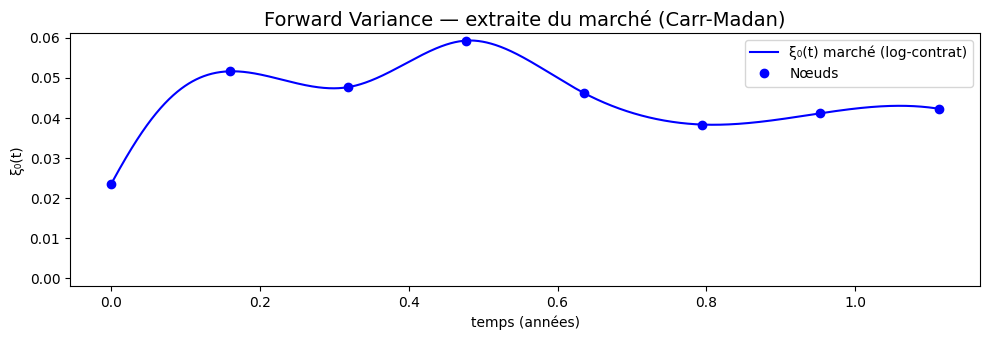


▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  PHASE 2 — ξ₀ paramétrique
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
[Slices] SPX: [9, 39]d, VIX: [9]d

PHASE 2 : Calibration ξ₀ paramétrique
  [  50] obj=4.0277 SPX=0.1050 VIX=0.9644 FUT=6.42
  [ 100] obj=4.1447 SPX=0.1023 VIX=0.2408 FUT=7.13
  [ 150] obj=5.3666 SPX=0.0618 VIX=0.7207 FUT=9.67
  [ 200] obj=3.9542 SPX=0.0691 VIX=0.2493 FUT=7.07
  [ 250] obj=6.0947 SPX=0.0648 VIX=0.4560 FUT=11.27
  [ 300] obj=0.6686 SPX=0.0415 VIX=0.7273 FUT=0.47
  [ 350] obj=4.1124 SPX=0.0931 VIX=0.2866 FUT=7.13
  [ 400] obj=1.2217 SPX=0.0366 VIX=0.5499 FUT=1.74
  [ 450] obj=0.5957 SPX=0.0288 VIX=0.5707 FUT=0.55
  [ 500] obj=1.0691 SPX=0.0242 VIX=0.0983 FUT=1.84
  [ 550] obj=2.0539 SPX=0.0692 VIX=0.1971 FUT=3.31
  [ 600] obj=2.3730 SPX=0.0607 VIX=0.5555 FUT=3.80
  [ 650] obj=2.6805 SPX=0.0418 VIX=0.9007 FUT=4.38
  [ 700] obj=0.8610 SPX=0.0473 VIX=0.1689 FUT=1.15
  [ 750] obj=6.0655 SPX=0.0784 VIX=0.5281 FUT=11.03
  [ 800] 

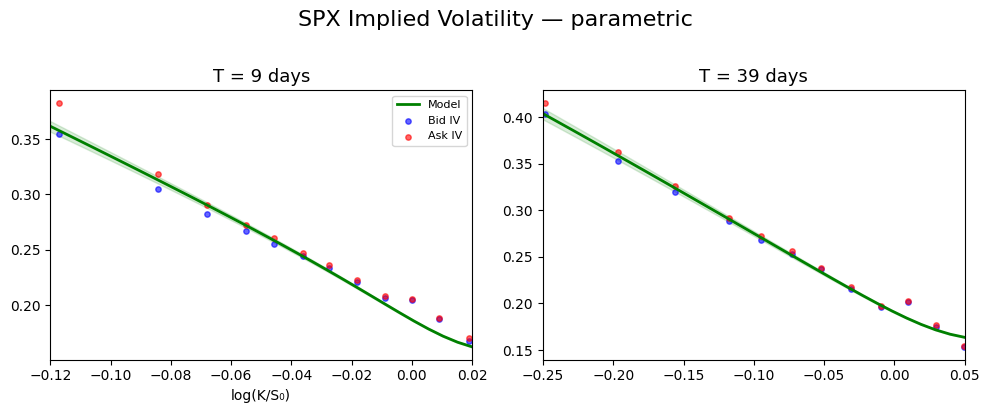

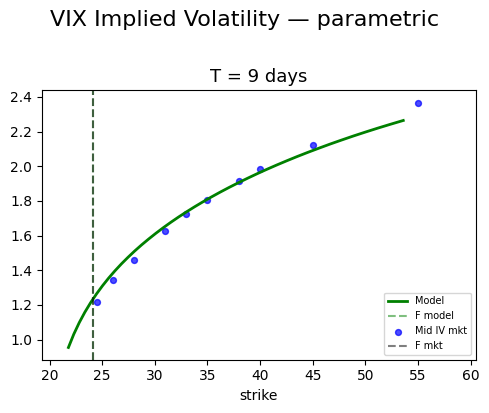


▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  PHASE 1 — ξ₀ spline (log-contrat)
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
[Slices] SPX: [9, 39, 193]d, VIX: [9, 163]d

PHASE 1 : Calibration ξ₀ spline (log-contrat)
  [  50] obj=10.0944
  [ 100] obj=10.6192
  [ 150] obj=10.5404
  [ 200] obj=3.5613
  [ 250] obj=3.3835
  [ 300] obj=3.0562
  [ 350] obj=4.5667
  [ 400] obj=5.4762
  [ 450] obj=2.8203
  [ 500] obj=3.4938
  [ 550] obj=2.0386
  [ 600] obj=8.8148
  [ 650] obj=4.7171
  [ 700] obj=4.0999
  [ 750] obj=3.7657
  [ 800] obj=9.5559
  [ 850] obj=2.3092
  [ 900] obj=3.4516
  [ 950] obj=0.7073
  [1000] obj=0.6016
  [1050] obj=6.4894
  [1100] obj=2.9897
  [1150] obj=5.2277
  [1200] obj=2.2073
  [1250] obj=1.4004
  [1300] obj=1.3661
  [1350] obj=10.0742
  [1400] obj=5.8365
  [1450] obj=8.2941
  [1500] obj=3.3672
  [1550] obj=4.9291
  [1600] obj=10.7544
  [1650] obj=2.9470
  [1700] obj=3.9448
  [1750] obj=1.4984
  [1800] obj=1.8452
  [1850] obj=0.5384
  [19

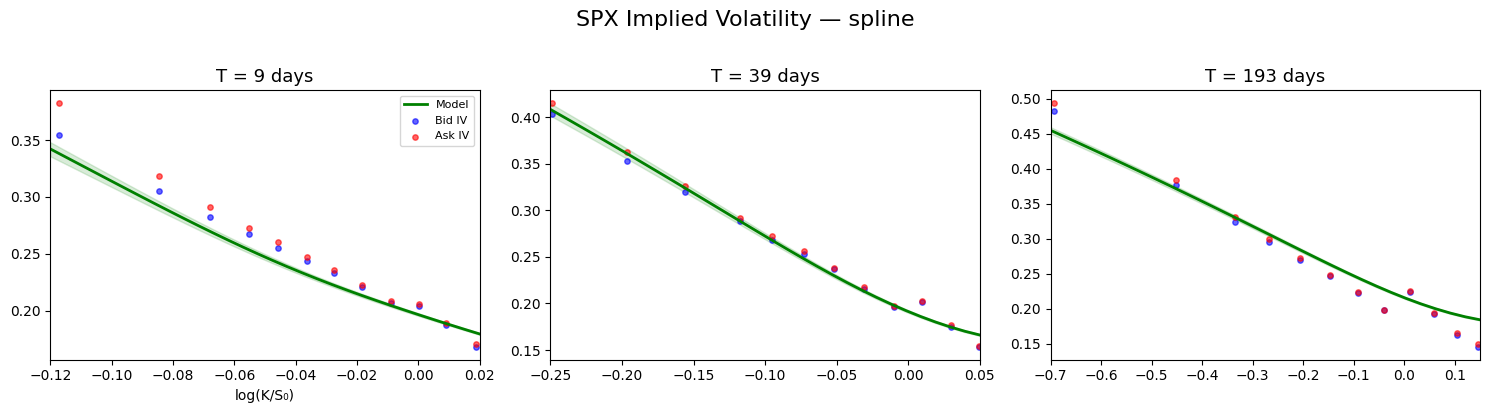

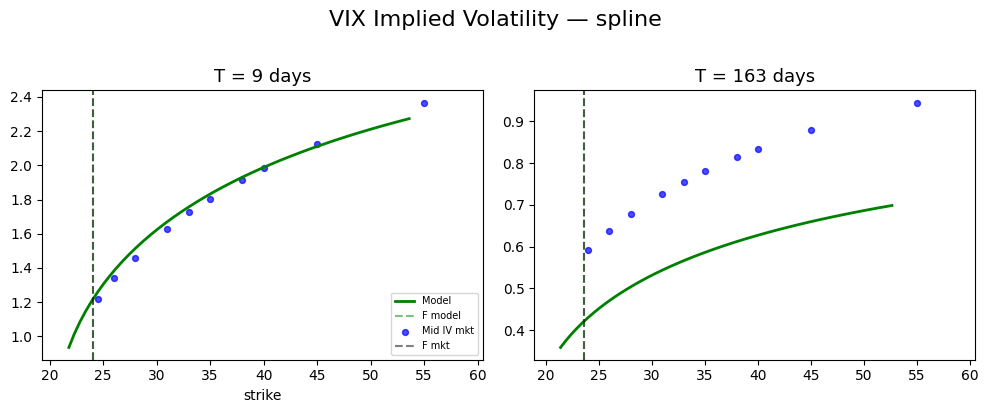

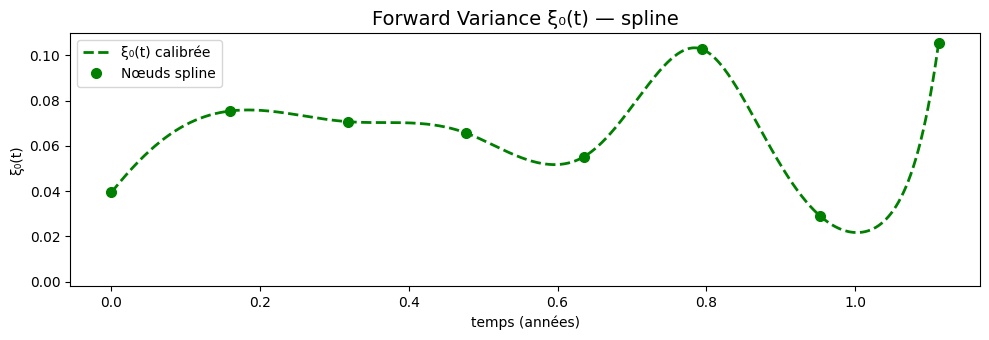


────────────────────────────────────────────────────────────
  ✅ VALEURS À COPIER DANS CELLULE 3 (réseau de neurones)
────────────────────────────────────────────────────────────
T_NODES_CAL = np.array([0.000000, 0.158904, 0.317808, 0.476712, 0.635616, 0.794521, 0.953425, 1.112329])
FV_CAL      = np.array([0.039453, 0.075359, 0.070672, 0.065698, 0.055241, 0.102626, 0.028886, 0.105497])
────────────────────────────────────────────────────────────

▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  PHASE 3 — H(t) variable
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
[Slices] SPX: [9, 39, 73, 193]d, VIX: [9, 43, 163]d

PHASE 3 : Calibration H(t) variable
  [  50] obj=6.6495
  [ 100] obj=11.0576
  [ 150] obj=1.5496
  [ 200] obj=4.8431
  [ 250] obj=9.8285
  [ 300] obj=3.1824
  [ 350] obj=6.1598
  [ 400] obj=3.4231
  [ 450] obj=4.4237
  [ 500] obj=5.2786
  [ 550] obj=5.4929
  [ 600] obj=5.9225
  [ 650] obj=2.5238
  [ 700] obj=4.0957
  [ 750] obj=7.4870
  [ 800] o

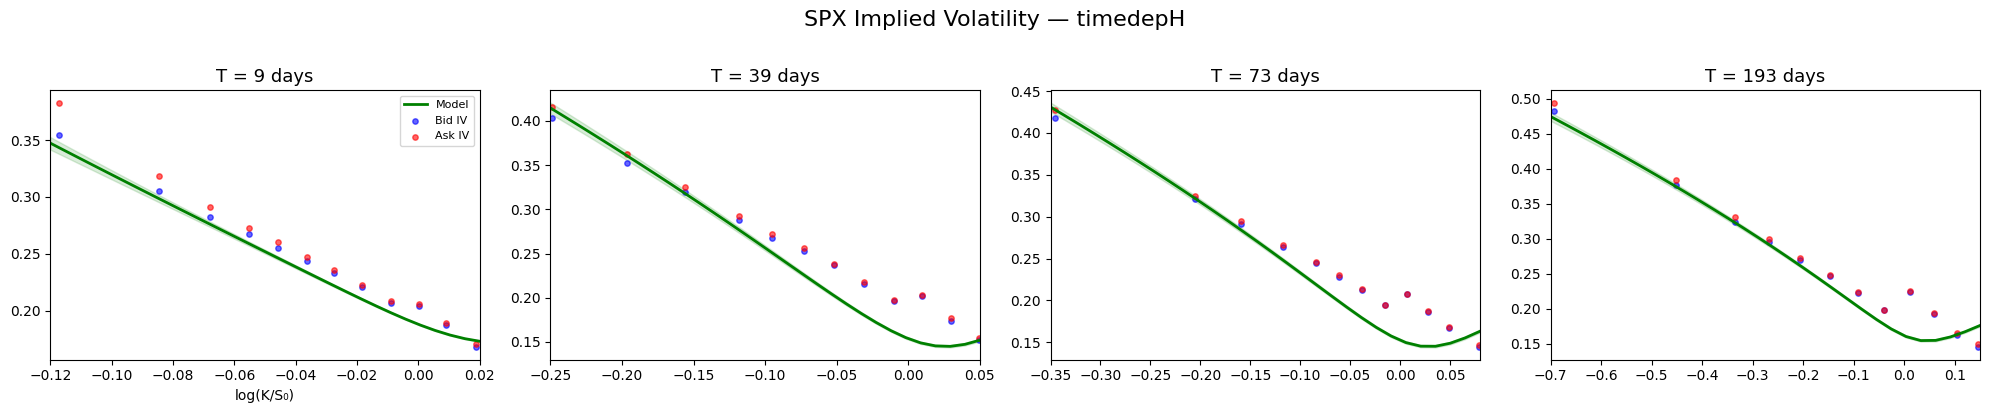

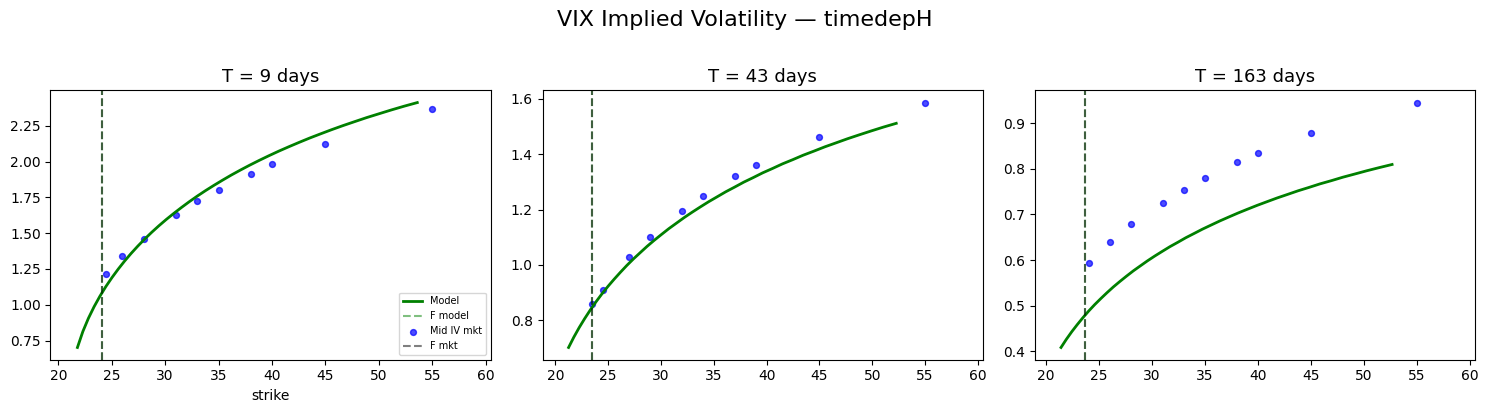

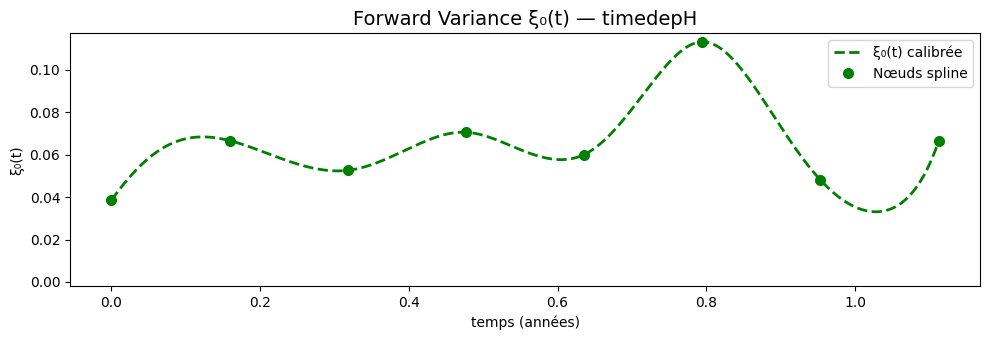

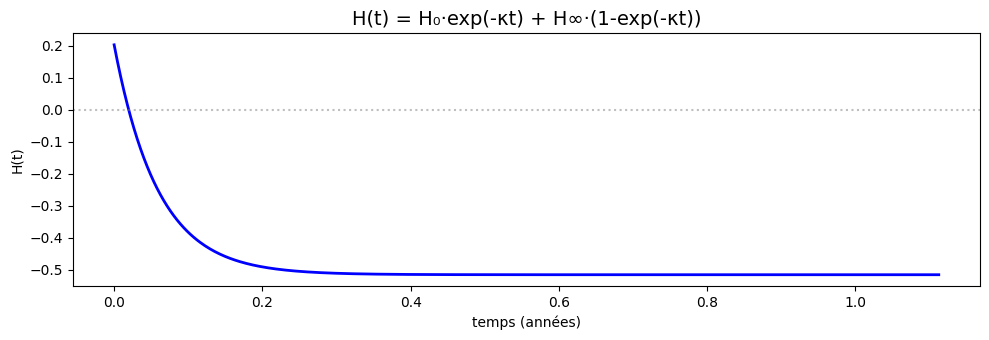


  RÉSUMÉ DE CALIBRATION

  ┌─ Phase 2 — ξ₀ paramétrique
  │  Objectif = 0.047865
  │  α = [0.4608, 0.9111, 0.0105, 0.070852]
  │  ρ = -0.6189
  │  H = 0.0784
  └  ε = 0.0192

  ┌─ Phase 1 — ξ₀ spline
  │  Objectif = 0.156137
  │  α = [0.9097, 0.4111, 0.6278, 0.090960]
  │  ρ = -0.6968
  │  H = 0.1203
  └  ε = 0.0192

  ┌─ Phase 3 — H(t) variable
  │  Objectif = 0.205857
  │  α = [0.3155, 0.7225, 0.1488, 0.142900]
  │  ρ = -0.4699
  │  H₀ = 0.2035, H∞ = -0.5157, κ = 16.8990
  └  ε = 0.0403

  Calibration terminée.


In [ ]:
"""
===================================================================================
  Quintic Ornstein-Uhlenbeck Volatility Model — Joint SPX/VIX Calibration
===================================================================================
  Reference: Abi Jaber, Illand & Li (2023), SSRN 4308677

  Phase 1 — Spline forward variance (log-contract extraction, Eq. 5.1)
  Phase 2 — Parametric ξ₀(t) = a·e^{-bt} + c·(1-e^{-bt})  (Eq. 5.2)
  Phase 3 — Time-dependent H(t) = H₀·e^{-κt} + H∞·(1-e^{-κt})  (Eq. 5.3)

  Calibration: c₁·RMSE_SPX + c₂·RMSE_VIX + c₃·RMSE_VIX_futures
  with c₁=1, c₂=0.1, c₃=0.5 (paper, Section 5).
===================================================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import interpolate, optimize
from math import exp, sqrt, log, pi
import warnings, os, json

warnings.filterwarnings('ignore')

try:
    from py_vollib.black_scholes.implied_volatility import implied_volatility
    vec_find_vol_rat = np.vectorize(implied_volatility)
    USE_VOLLIB = True
except ImportError:
    USE_VOLLIB = False

# ==========================================================================
# SECTION 1: UTILITY FUNCTIONS (identiques au notebook de l'auteur)
# ==========================================================================

def bs_price_call(s, sigma, T, K):
    """Prix Black-Scholes d'un call (taux=0, dividendes=0)."""
    d1 = (np.log(s / K) + 0.5 * np.power(sigma, 2.0) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return s * scipy.special.ndtr(d1) - K * scipy.special.ndtr(d2)


def bs_iv_bisection(price, S, K, T, r=0.0, flag='c', tol=1e-8, max_iter=100):
    """Implied volatility par bisection (fallback si py_vollib absent)."""
    if price <= 0: return 1e-10
    intrinsic = max(S - K, 0) if flag == 'c' else max(K - S, 0)
    if price < intrinsic + 1e-12: return 1e-10
    lo, hi = 1e-6, 10.0
    for _ in range(max_iter):
        mid = (lo + hi) / 2.0
        p = bs_price_call(S, mid, T, K) if flag == 'c' else bs_price_call(S, mid, T, K) - S + K
        if p > price: hi = mid
        else: lo = mid
        if hi - lo < tol: break
    return (lo + hi) / 2.0

if not USE_VOLLIB:
    vec_find_vol_rat = np.vectorize(bs_iv_bisection)


def horner_vector(poly, n, x):
    """Évaluation polynomiale vectorisée par méthode de Horner.
    poly = coefficients du degré le plus haut au plus bas."""
    result = poly[0].reshape(-1, 1)
    for i in range(1, n):
        result = result * x + poly[i].reshape(-1, 1)
    return result


def doublefactorial(n):
    """Double factorielle n!! pour les moments gaussiens."""
    if n <= 0: return 1
    return n * doublefactorial(n - 2)


def gen_bm_path(n_steps, N_sims):
    """Génère des incréments browniens avec variantes antithétiques.
    Retourne (n_steps, 2·N_sims)."""
    w1 = np.random.normal(0, 1, (n_steps, N_sims))
    return np.concatenate((w1, -w1), axis=1)


def gauss_dens(mu, sigma, x):
    """Densité gaussienne N(μ, σ²)."""
    return 1 / np.sqrt(2 * pi * sigma**2) * np.exp(-(x - mu)**2 / (2 * sigma**2))


def spx_lm_range_rule(T_mat):
    """Plage de log-moneyness adaptée à la maturité T (comme dans le notebook).
    Maturités courtes → plage étroite (le smile est concentré near-ATM)."""
    if T_mat < 2 / 52:   return [-0.12, 0.02]
    elif T_mat < 1 / 12:  return [-0.15, 0.03]
    elif T_mat < 2 / 12:  return [-0.25, 0.05]
    elif T_mat < 3 / 12:  return [-0.35, 0.08]
    elif T_mat < 6 / 12:  return [-0.50, 0.10]
    else:                  return [-0.70, 0.15]


# ==========================================================================
# SECTION 2: PRÉTRAITEMENT DES DONNÉES
# ==========================================================================

def preprocess_spx(spx_raw):
    """
    Prétraitement robuste des options SPX :
      1. Redéfinir OTM manuellement : puts K<S₀, calls K>S₀
      2. Filtrer par plage de log-moneyness adaptée à chaque maturité
      3. Supprimer bid=0 et IVs extrêmes
      4. Garder les slices avec ≥10 options propres

    Retourne : spx_clean DataFrame, S0 float
    """
    spx = spx_raw.copy()
    S0 = spx['S0'].iloc[0]

    # Redéfinir OTM nous-mêmes (le champ is_otm du CSV peut être incorrect)
    spx['is_otm_manual'] = (
        ((spx['option_type'] == 'P') & (spx['strike'] < S0)) |
        ((spx['option_type'] == 'C') & (spx['strike'] >= S0))
    )
    spx = spx[spx['is_otm_manual']].copy()

    # Filtrage global
    spx = spx[spx['bid_price'] > 0.50]       # liquidité minimale
    spx = spx[(spx['mid_iv'] > 0.05) & (spx['mid_iv'] < 1.5)]  # IV raisonnables

    # Filtrage par log-moneyness adapté à chaque maturité
    keep = []
    for T_val in spx['T'].unique():
        lm_lo, lm_hi = spx_lm_range_rule(T_val)
        mask = (
            np.isclose(spx['T'], T_val, atol=1e-8) &
            (spx['log_moneyness'] >= lm_lo) &
            (spx['log_moneyness'] <= lm_hi)
        )
        keep.append(mask)
    spx = spx[pd.concat(keep, axis=1).any(axis=1) if len(keep) > 1
              else keep[0]].copy()

    # Recalcul plus propre : filtrer slice par slice
    spx_filtered = []
    for T_val in spx['T'].unique():
        sl = spx[np.isclose(spx['T'], T_val, atol=1e-8)]
        lm_lo, lm_hi = spx_lm_range_rule(T_val)
        sl = sl[(sl['log_moneyness'] >= lm_lo) & (sl['log_moneyness'] <= lm_hi)]
        if len(sl) >= 10:
            spx_filtered.append(sl)
    spx = pd.concat(spx_filtered, ignore_index=True) if spx_filtered else pd.DataFrame()

    # Estimer bid/ask IV (approximation via le spread prix)
    spx['iv_spread'] = np.where(
        spx['mid_price'] > 1,
        spx['bid_ask_spread'] / spx['mid_price'] * spx['mid_iv'],
        0.01
    )
    spx['bid_iv'] = np.maximum(spx['mid_iv'] - spx['iv_spread'] / 2, 0.01)
    spx['ask_iv'] = spx['mid_iv'] + spx['iv_spread'] / 2

    n_slices = spx['T'].nunique()
    print(f"[SPX] {len(spx)} options, {n_slices} maturités (S0={S0:.2f})")
    return spx, S0


def estimate_vix_forwards(vix_raw):
    """
    Estime les VIX forwards par parité put-call :
      F = K + C(K) - P(K), moyenné near-ATM.

    Le champ vix_future_price du CSV contient le VIX spot pour toutes les
    maturités → inutilisable directement pour la calibration.
    """
    vix = vix_raw.copy()
    vix_spot = vix['vix_spot'].iloc[0]

    forwards = {}
    for exp in vix['expiry'].unique():
        sl = vix[vix['expiry'] == exp]
        T = sl['T'].iloc[0]
        calls = sl[sl['option_type'] == 'C'].set_index('strike')['mid_price']
        puts = sl[sl['option_type'] == 'P'].set_index('strike')['mid_price']
        common = calls.index.intersection(puts.index)
        if len(common) >= 2:
            F_est = common.values + calls[common].values - puts[common].values
            # Moyenne pondérée near-ATM
            weights = 1 / (1 + (common.values - vix_spot)**2)
            F_avg = np.average(F_est, weights=weights)
            forwards[exp] = max(F_avg, 5.0)  # plancher de sécurité
        else:
            forwards[exp] = vix_spot  # fallback

    return forwards


def preprocess_vix(vix_raw, vix_forwards):
    """
    Prétraitement robuste des options VIX :
      1. Remplacer vix_future_price par les forwards estimés
      2. Garder OTM calls (K > F) — portent l'info du smile ascendant VIX
      3. Filtrer bid>0, IV raisonnables
      4. Restreindre les strikes : F < K < 3·F (éviter far-OTM extrêmes)
    """
    vix = vix_raw.copy()

    # Remplacer le forward par l'estimation put-call parity
    vix['vix_future_est'] = vix['expiry'].map(vix_forwards)

    # Garder uniquement les OTM calls
    vix = vix[
        (vix['option_type'] == 'C') &
        (vix['strike'] > vix['vix_future_est'])
    ].copy()

    # Filtres de qualité
    vix = vix[vix['bid_price'] > 0.05]
    vix = vix[(vix['mid_iv'] > 0.1) & (vix['mid_iv'] < 5.0)]

    # Restreindre les strikes : F < K < 2.5·F
    vix = vix[vix['strike'] <= 2.5 * vix['vix_future_est']]

    # Supprimer slices avec < 5 options
    counts = vix.groupby('expiry').size()
    valid = counts[counts >= 5].index
    vix = vix[vix['expiry'].isin(valid)]

    # IV spread approximatif
    vix['iv_spread'] = np.where(
        vix['mid_price'] > 0.1,
        vix['bid_ask_spread'] / vix['mid_price'] * vix['mid_iv'],
        0.05
    )
    vix['bid_iv'] = np.maximum(vix['mid_iv'] - vix['iv_spread'] / 2, 0.01)
    vix['ask_iv'] = vix['mid_iv'] + vix['iv_spread'] / 2

    n_slices = vix['expiry'].nunique()
    vix_spot = vix_raw['vix_spot'].iloc[0]
    print(f"[VIX] {len(vix)} OTM calls, {n_slices} maturités (VIX spot={vix_spot:.2f})")
    return vix


def select_slices(spx, vix, n_spx=3, n_vix=2, min_T=7/365):
    """
    Sélectionne des tranches de maturité bien espacées pour la calibration.
    Exclut les maturités < 1 semaine (trop bruitées).
    """
    spx_T = np.sort(spx[spx['T'] > min_T]['T'].unique())
    vix_T = np.sort(vix[vix['T'] > min_T]['T'].unique())

    # VIX : sélection uniforme
    if len(vix_T) <= n_vix:
        vix_mats = vix_T
    else:
        idx = np.linspace(0, len(vix_T) - 1, n_vix).astype(int)
        vix_mats = vix_T[idx]

    # SPX : au moins une maturité ≈ chaque VIX mat, + quelques extras
    spx_targets = np.unique(np.concatenate([vix_mats, vix_mats + 30/365]))
    spx_selected = []
    for t in spx_targets:
        if len(spx_T) > 0:
            best = spx_T[np.argmin(np.abs(spx_T - t))]
            spx_selected.append(best)
    spx_mats = np.unique(spx_selected)
    if len(spx_mats) > n_spx:
        idx = np.linspace(0, len(spx_mats) - 1, n_spx).astype(int)
        spx_mats = spx_mats[idx]

    # Construire les dictionnaires de slices
    spx_slices = {t: spx[np.isclose(spx['T'], t, atol=1e-6)].copy() for t in spx_mats}
    vix_slices = {t: vix[np.isclose(vix['T'], t, atol=1e-6)].copy() for t in vix_mats}

    print(f"[Slices] SPX: {[int(round(t*365)) for t in spx_mats]}d, "
          f"VIX: {[int(round(t*365)) for t in vix_mats]}d")
    return spx_mats, vix_mats, spx_slices, vix_slices


def extract_forward_variance(spx, S0, n_nodes=8):
    """
    Extraction de la courbe de variance forward ξ₀(t) par réplication
    du log-contrat de Carr-Madan (Eq. 5.1 du papier).

    Pour chaque maturité, intègre 2·∫ OTM_price(K)/K² dK par trapèzes.
    Puis différence entre maturités successives pour obtenir la variance forward.
    """
    maturities = np.sort(spx['T'].unique())
    cum_var = [0.0]

    for T in maturities:
        sl = spx[np.isclose(spx['T'], T, atol=1e-6)]
        if len(sl) < 8:
            continue
        strikes = sl['strike'].values
        ivs = sl['mid_iv'].values
        sort_idx = np.argsort(strikes)
        strikes, ivs = strikes[sort_idx], ivs[sort_idx]

        # Prix OTM via BS
        otm_prices = np.zeros_like(strikes, dtype=float)
        for j in range(len(strikes)):
            K, sigma = strikes[j], ivs[j]
            if sigma < 1e-4: continue
            d1 = (np.log(S0 / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
            d2 = d1 - sigma * np.sqrt(T)
            if K <= S0:  # OTM put
                otm_prices[j] = K * scipy.special.ndtr(-d2) - S0 * scipy.special.ndtr(-d1)
            else:  # OTM call
                otm_prices[j] = S0 * scipy.special.ndtr(d1) - K * scipy.special.ndtr(d2)
            otm_prices[j] = max(otm_prices[j], 0.0)

        integrand = 2.0 * otm_prices / strikes**2
        integral = np.trapezoid(integrand, strikes)
        cum_var.append(integral)

    mats_with_0 = np.concatenate(([0.0], maturities[:len(cum_var) - 1]))
    cum_var = np.array(cum_var)

    # Forward variance = dérivée de la variance cumulée
    T_nodes, fv_vals = [0.0], []
    for i in range(len(mats_with_0) - 1):
        dt = mats_with_0[i + 1] - mats_with_0[i]
        if dt > 0:
            fv = max((cum_var[i + 1] - cum_var[i]) / dt, 1e-6)
            T_nodes.append((mats_with_0[i] + mats_with_0[i + 1]) / 2)
            fv_vals.append(fv)

    T_nodes = np.array(T_nodes)
    fv_vals = np.array([fv_vals[0]] + list(fv_vals))

    # Sous-échantillonner à n_nodes nœuds
    T_compact = np.linspace(T_nodes[0], T_nodes[-1], n_nodes)
    fv_compact = np.interp(T_compact, T_nodes, fv_vals)

    print(f"[Fwd var] {n_nodes} nœuds sur [{T_compact[0]:.3f}, {T_compact[-1]:.3f}], "
          f"ξ₀ ∈ [{fv_compact.min():.5f}, {fv_compact.max():.5f}]")
    return T_compact, fv_compact


# ==========================================================================
# SECTION 3: PRICING SPX — Monte Carlo exact OU + turbocharging
# ==========================================================================

def mc_spx_spline(rho, H, eps, T, a_k_part, S0, strike_array,
                  n_steps, N_sims, fv_nodes, T_nodes, w1, compute_iv=True):
    """
    Prix MC de calls SPX avec ξ₀ interpolée par spline cubique sur √ξ₀.
    Simulation exacte du processus OU + turbocharging (McCrickerd & Pakkanen 2018).
    """
    eta = eps**(H - 0.5)
    kappa = (0.5 - H) / eps
    a0, a1, a3, a5 = a_k_part
    a_k = np.array([a0, a1, 0, a3, 0, a5])

    dt = T / n_steps
    tt = np.linspace(0., T, n_steps + 1)

    # Simulation exacte de X (OU gaussien)
    exp1 = np.exp(kappa * tt)
    exp2 = np.exp(2 * kappa * tt)
    diff_exp2 = np.concatenate(([0.], np.diff(exp2)))
    std_vec = np.sqrt(diff_exp2 / (2 * kappa))[:, np.newaxis]
    exp1_col = exp1[:, np.newaxis]
    X = (1 / exp1_col) * (eta * np.cumsum(std_vec * w1, axis=0))
    Xt = X[:-1]

    tt_sim = tt[:-1]
    std_Xt = np.sqrt(eta**2 / (2 * kappa) * (1 - np.exp(-2 * kappa * tt_sim)))
    n = len(a_k)

    # Normalisation E[p(X_t)²]
    cp = np.convolve(a_k, a_k)
    normal_var = np.sum(
        cp[np.arange(0, 2*n, 2)].reshape(-1, 1) *
        std_Xt**(np.arange(0, 2*n, 2).reshape(-1, 1)) *
        np.array([doublefactorial(z) for z in np.arange(0, 2*n, 2) - 1]).reshape(-1, 1),
        axis=0)

    f_func = horner_vector(a_k[::-1], len(a_k), Xt)

    # Spline sur √ξ₀ → carré pour positivité
    spl = interpolate.splrep(T_nodes, np.sqrt(fv_nodes), k=3)
    fv = (interpolate.splev(tt_sim, spl, der=0).reshape(-1, 1))**2

    vol = np.sqrt(fv) * f_func / np.sqrt(normal_var.reshape(-1, 1))

    # Euler sur log(S^W) — partie FW-mesurable
    logS = log(S0)
    for i in range(w1.shape[0] - 1):
        logS = logS - 0.5 * dt * (vol[i] * rho)**2 + sqrt(dt) * rho * vol[i] * w1[i + 1]
    ST = np.exp(logS)

    # Turbocharging : variante de contrôle
    int_var = np.sum(vol[:-1]**2 * dt, axis=0)
    Q = np.max(int_var) + 1e-9
    Xp = bs_price_call(ST, np.sqrt((1 - rho**2) * int_var / T), T, strike_array.reshape(-1, 1)).T
    Yp = bs_price_call(ST, np.sqrt(rho**2 * (Q - int_var) / T), T, strike_array.reshape(-1, 1)).T
    eY = bs_price_call(S0, np.sqrt(rho**2 * Q / T), T, strike_array.reshape(-1, 1)).T

    # Coefficient optimal de contrôle
    c_cv = []
    for i in range(len(strike_array)):
        cov_xy = np.cov(Xp[:, i] + 10, Yp[:, i] + 10)
        c_cv.append(np.clip(cov_xy[0, 1] / max(cov_xy[1, 1], 1e-12), -2, 2))
    c_cv = np.array(c_cv)

    mc_est = Xp - c_cv * (Yp - eY)
    prices = np.mean(mc_est, axis=0)
    stds = np.std(mc_est, axis=0)

    if compute_iv:
        iv = vec_find_vol_rat(prices, S0, strike_array, T, 0.0, 'c')
        iv_u = vec_find_vol_rat(prices + 1.96 * stds / np.sqrt(2 * N_sims), S0, strike_array, T, 0.0, 'c')
        iv_l = vec_find_vol_rat(prices - 1.96 * stds / np.sqrt(2 * N_sims), S0, strike_array, T, 0.0, 'c')
        return prices, stds, iv, iv_u, iv_l
    return prices, stds


def mc_spx_parametric(rho, H, eps, T, a_k_part, a, b, c_fv,
                       S0, strike_array, n_steps, N_sims, w1, compute_iv=True):
    """Prix MC de calls SPX avec ξ₀(t) = a·e^{-bt} + c·(1-e^{-bt}) (Eq. 5.2)."""
    eta = eps**(H - 0.5)
    kappa = (0.5 - H) / eps
    a0, a1, a3, a5 = a_k_part
    a_k = np.array([a0, a1, 0, a3, 0, a5])

    dt = T / n_steps
    tt = np.linspace(0., T, n_steps + 1)

    exp1 = np.exp(kappa * tt)
    exp2 = np.exp(2 * kappa * tt)
    diff_exp2 = np.concatenate(([0.], np.diff(exp2)))
    std_vec = np.sqrt(diff_exp2 / (2 * kappa))[:, np.newaxis]
    X = (1 / exp1[:, np.newaxis]) * (eta * np.cumsum(std_vec * w1, axis=0))
    Xt = X[:-1]

    tt_sim = tt[:-1]
    std_Xt = np.sqrt(eta**2 / (2 * kappa) * (1 - np.exp(-2 * kappa * tt_sim)))
    n = len(a_k)
    cp = np.convolve(a_k, a_k)
    normal_var = np.sum(
        cp[np.arange(0, 2*n, 2)].reshape(-1, 1) *
        std_Xt**(np.arange(0, 2*n, 2).reshape(-1, 1)) *
        np.array([doublefactorial(z) for z in np.arange(0, 2*n, 2) - 1]).reshape(-1, 1),
        axis=0)
    f_func = horner_vector(a_k[::-1], len(a_k), Xt)

    fv = (a * np.exp(-b * tt_sim) + c_fv * (1 - np.exp(-b * tt_sim))).reshape(-1, 1)
    vol = np.sqrt(fv) * f_func / np.sqrt(normal_var.reshape(-1, 1))

    logS = log(S0)
    for i in range(w1.shape[0] - 1):
        logS = logS - 0.5 * dt * (vol[i] * rho)**2 + sqrt(dt) * rho * vol[i] * w1[i + 1]
    ST = np.exp(logS)

    int_var = np.sum(vol[:-1]**2 * dt, axis=0)
    Q = np.max(int_var) + 1e-9
    Xp = bs_price_call(ST, np.sqrt((1 - rho**2) * int_var / T), T, strike_array.reshape(-1, 1)).T
    Yp = bs_price_call(ST, np.sqrt(rho**2 * (Q - int_var) / T), T, strike_array.reshape(-1, 1)).T
    eY = bs_price_call(S0, np.sqrt(rho**2 * Q / T), T, strike_array.reshape(-1, 1)).T
    c_cv = []
    for i in range(len(strike_array)):
        cov_xy = np.cov(Xp[:, i] + 10, Yp[:, i] + 10)
        c_cv.append(np.clip(cov_xy[0, 1] / max(cov_xy[1, 1], 1e-12), -2, 2))
    mc_est = Xp - np.array(c_cv) * (Yp - eY)
    prices = np.mean(mc_est, axis=0)
    stds = np.std(mc_est, axis=0)

    if compute_iv:
        iv = vec_find_vol_rat(prices, S0, strike_array, T, 0.0, 'c')
        iv_u = vec_find_vol_rat(prices + 1.96 * stds / np.sqrt(2 * N_sims), S0, strike_array, T, 0.0, 'c')
        iv_l = vec_find_vol_rat(prices - 1.96 * stds / np.sqrt(2 * N_sims), S0, strike_array, T, 0.0, 'c')
        return prices, stds, iv, iv_u, iv_l
    return prices, stds


# Nœuds Gauss-Legendre pour intégrales du H(t) variable
x_org_h, w_org_h = np.polynomial.legendre.leggauss(100)

def mc_spx_timedepH(rho, H0, Hinf, Hmr, eps, T, a_k_part, S0, strike_array,
                     n_steps, N_sims, fv_nodes, T_nodes, w1, compute_iv=True):
    """Prix MC de calls SPX avec H(t) = H₀e^{-κt} + H∞(1-e^{-κt}) (Eq. 5.3)."""
    a0, a1, a3, a5 = a_k_part
    a_k = np.array([a0, a1, 0, a3, 0, a5])
    dt = T / n_steps
    tt = np.linspace(0., T, n_steps + 1)

    # Exponent intégré : ∫₀ᵗ (1/2-H(s))/ε ds
    exp1 = np.exp(1/(2*eps)*tt - 1/eps*(H0/Hmr*(1-np.exp(-Hmr*tt)) +
                  Hinf*tt - Hinf/Hmr*(1-np.exp(-Hmr*tt))))
    # Variance par quadrature GL
    tt_d = 0.5*(x_org_h+1)*(tt[1:]-tt[:-1]).reshape(-1,1) + tt[:-1].reshape(-1,1)
    w_d = w_org_h/2*(tt[1:]-tt[:-1]).reshape(-1,1)
    kap_d = 1/(2*eps)*tt_d - 1/eps*(H0/Hmr*(1-np.exp(-Hmr*tt_d)) +
             Hinf*tt_d - Hinf/Hmr*(1-np.exp(-Hmr*tt_d)))
    H_d = H0*np.exp(-Hmr*tt_d) + Hinf*(1-np.exp(-Hmr*tt_d))
    eta_d = eps**(H_d - 0.5)
    var_inc = np.sum(eta_d**2 * np.exp(2*kap_d) * w_d, axis=1)
    var_inc = np.concatenate(([0.], var_inc))
    std_inc = np.sqrt(var_inc)[:, np.newaxis]
    std_Xt = np.sqrt(np.cumsum(var_inc)) / exp1

    Xt = (1/exp1[:, np.newaxis]) * np.cumsum(std_inc * w1, axis=0)
    Xt = Xt[:-1]
    tt_sim = tt[:-1]
    std_Xt = std_Xt[:-1]
    n = len(a_k)
    cp = np.convolve(a_k, a_k)
    normal_var = np.sum(
        cp[np.arange(0, 2*n, 2)].reshape(-1,1) *
        std_Xt**(np.arange(0, 2*n, 2).reshape(-1,1)) *
        np.array([doublefactorial(z) for z in np.arange(0, 2*n, 2)-1]).reshape(-1,1),
        axis=0)
    f_func = horner_vector(a_k[::-1], len(a_k), Xt)
    spl = interpolate.splrep(T_nodes, np.sqrt(fv_nodes), k=3)
    fv = (interpolate.splev(tt_sim, spl, der=0).reshape(-1,1))**2
    vol = np.sqrt(fv) * f_func / np.sqrt(normal_var.reshape(-1,1))

    logS = log(S0)
    for i in range(w1.shape[0]-1):
        logS = logS - 0.5*dt*(vol[i]*rho)**2 + sqrt(dt)*rho*vol[i]*w1[i+1]
    ST = np.exp(logS)
    int_var = np.sum(vol[:-1]**2*dt, axis=0)
    Q = np.max(int_var) + 1e-9
    Xp = bs_price_call(ST, np.sqrt((1-rho**2)*int_var/T), T, strike_array.reshape(-1,1)).T
    Yp = bs_price_call(ST, np.sqrt(rho**2*(Q-int_var)/T), T, strike_array.reshape(-1,1)).T
    eY = bs_price_call(S0, np.sqrt(rho**2*Q/T), T, strike_array.reshape(-1,1)).T
    c_cv = []
    for i in range(len(strike_array)):
        cov_xy = np.cov(Xp[:,i]+10, Yp[:,i]+10)
        c_cv.append(np.clip(cov_xy[0,1]/max(cov_xy[1,1],1e-12), -2, 2))
    mc_est = Xp - np.array(c_cv)*(Yp - eY)
    prices = np.mean(mc_est, axis=0)
    stds = np.std(mc_est, axis=0)
    if compute_iv:
        iv = vec_find_vol_rat(prices, S0, strike_array, T, 0.0, 'c')
        iv_u = vec_find_vol_rat(prices + 1.96*stds/np.sqrt(2*N_sims), S0, strike_array, T, 0.0, 'c')
        iv_l = vec_find_vol_rat(prices - 1.96*stds/np.sqrt(2*N_sims), S0, strike_array, T, 0.0, 'c')
        return prices, stds, iv, iv_u, iv_l
    return prices, stds


# ==========================================================================
# SECTION 4: PRICING VIX — Gauss-Legendre (Eq. 3.3-3.4)
# ==========================================================================

def vix_spline(H, eps, T, a_k_part, x_gl, w_gl, strike_perc,
               fv_nodes, T_nodes, lb=-8, ub=8, n_steps=200, compute_iv=True):
    """VIX pricing par quadrature GL avec ξ₀ spline."""
    a_k = np.array([a_k_part[0], a_k_part[1], 0, a_k_part[2], 0, a_k_part[3]])
    kappa = (0.5 - H)/eps;  eta = eps**(H - 0.5)
    delt = 30/360;  T_d = T + delt
    w = w_gl/2*(ub - lb)
    y = (ub - lb)/2*x_gl + (ub + lb)/2
    dt = delt/n_steps
    tt = np.linspace(T, T_d, n_steps + 1)

    exp_det = np.exp(-kappa*(tt - T))
    cp = np.convolve(a_k, a_k)
    std_G = eta*np.sqrt(1/(2*kappa)*(1 - np.exp(-2*kappa*(tt - T))))
    std_Xu = eta*np.sqrt(1/(2*kappa)*(1 - np.exp(-2*kappa*tt)))
    std_XT = eta*np.sqrt(1/(2*kappa)*(1 - np.exp(-2*kappa*T)))
    n = len(a_k)
    nv = np.sum(cp[np.arange(0,2*n,2)].reshape(-1,1) *
                std_Xu**(np.arange(0,2*n,2).reshape(-1,1)) *
                np.array([doublefactorial(z) for z in np.arange(0,2*n,2)-1]).reshape(-1,1), axis=0)
    spl = interpolate.splrep(T_nodes, np.sqrt(fv_nodes), k=3)
    FV = interpolate.splev(tt, spl, der=0)**2

    beta = []
    for i in range(0, 2*n - 1):
        k_arr = np.arange(i, 2*n - 1)
        bt = ((std_G**((k_arr-i).reshape(-1,1)) *
               ((k_arr-i-1)%2).reshape(-1,1) *
               np.array([doublefactorial(z) for z in k_arr-i-1]).reshape(-1,1) *
               scipy.special.comb(k_arr, i).reshape(-1,1)) *
              exp_det**i) * cp[k_arr].reshape(-1,1)
        beta.append(np.sum(bt, axis=0))
    beta = np.array(beta) * FV / nv
    beta = np.sum((beta[:, :-1] + beta[:, 1:])/2, axis=1) * dt

    vix_T = np.sqrt(horner_vector(beta[::-1], len(beta), std_XT*y.reshape(1,-1)) / delt)
    dens = gauss_dens(0., 1, y)
    Ft = np.sum(dens*vix_T*w)
    opt = np.sum(dens*np.maximum(vix_T - Ft*strike_perc.reshape(-1,1), 0)*w, axis=1)
    if compute_iv:
        iv = vec_find_vol_rat(opt, Ft, strike_perc*Ft, T, 0.0, 'c')
        return Ft*100, opt*100, iv
    return Ft*100, opt*100


def vix_parametric(H, eps, T, a_k_part, a, b, c_fv, x_gl, w_gl, strike_perc,
                    lb=-8, ub=8, n_steps=200, compute_iv=True):
    """VIX pricing avec ξ₀(t) = a·e^{-bt} + c·(1-e^{-bt})."""
    a_k = np.array([a_k_part[0], a_k_part[1], 0, a_k_part[2], 0, a_k_part[3]])
    kappa = (0.5 - H)/eps;  eta = eps**(H - 0.5)
    delt = 30/360;  T_d = T + delt
    w = w_gl/2*(ub - lb)
    y = (ub - lb)/2*x_gl + (ub + lb)/2
    dt = delt/n_steps
    tt = np.linspace(T, T_d, n_steps + 1)

    FV = a*np.exp(-b*tt) + c_fv*(1 - np.exp(-b*tt))
    exp_det = np.exp(-kappa*(tt - T))
    cp = np.convolve(a_k, a_k)
    std_G = eta*np.sqrt(1/(2*kappa)*(1 - np.exp(-2*kappa*(tt - T))))
    std_Xu = eta*np.sqrt(1/(2*kappa)*(1 - np.exp(-2*kappa*tt)))
    std_XT = eta*np.sqrt(1/(2*kappa)*(1 - np.exp(-2*kappa*T)))
    n = len(a_k)
    nv = np.sum(cp[np.arange(0,2*n,2)].reshape(-1,1) *
                std_Xu**(np.arange(0,2*n,2).reshape(-1,1)) *
                np.array([doublefactorial(z) for z in np.arange(0,2*n,2)-1]).reshape(-1,1), axis=0)

    beta = []
    for i in range(0, 2*n - 1):
        k_arr = np.arange(i, 2*n - 1)
        bt = ((std_G**((k_arr-i).reshape(-1,1)) * ((k_arr-i-1)%2).reshape(-1,1) *
               np.array([doublefactorial(z) for z in k_arr-i-1]).reshape(-1,1) *
               scipy.special.comb(k_arr, i).reshape(-1,1)) *
              exp_det**i) * cp[k_arr].reshape(-1,1)
        beta.append(np.sum(bt, axis=0))
    beta = np.array(beta) * FV / nv
    beta = np.sum((beta[:, :-1] + beta[:, 1:])/2, axis=1) * dt

    vix_T = np.sqrt(horner_vector(beta[::-1], len(beta), std_XT*y.reshape(1,-1)) / delt)
    dens = gauss_dens(0., 1, y)
    Ft = np.sum(dens*vix_T*w)
    opt = np.sum(dens*np.maximum(vix_T - Ft*strike_perc.reshape(-1,1), 0)*w, axis=1)
    if compute_iv:
        iv = vec_find_vol_rat(opt, Ft, strike_perc*Ft, T, 0.0, 'c')
        return Ft*100, opt*100, iv
    return Ft*100, opt*100


def vix_timedepH(H0, Hinf, Hmr, eps, T, a_k_part, x_gl, w_gl, strike_perc,
                  fv_nodes, T_nodes, lb=-8, ub=8, n_steps=200, compute_iv=True):
    """VIX pricing avec H(t) variable (Eq. 5.3)."""
    a_k = np.array([a_k_part[0], a_k_part[1], 0, a_k_part[2], 0, a_k_part[3]])
    delt = 30/360;  T_d = T + delt
    w = w_gl/2*(ub - lb)
    y = (ub - lb)/2*x_gl + (ub + lb)/2
    dt = delt/n_steps
    tt = np.linspace(T, T_d, n_steps + 1)

    kap_XT = 1/(2*eps)*T - 1/eps*(H0/Hmr*(1-np.exp(-Hmr*T)) + Hinf*T - Hinf/Hmr*(1-np.exp(-Hmr*T)))
    kap_det = 1/(2*eps)*tt - 1/eps*(H0/Hmr*(1-np.exp(-Hmr*tt)) + Hinf*tt - Hinf/Hmr*(1-np.exp(-Hmr*tt)))
    exp_det = np.exp(-kap_det + kap_XT)

    # σ_{X_u} par quadrature
    w_t = w_org_h/2*tt.reshape(-1,1)
    ttt = 0.5*(x_org_h+1)*tt.reshape(-1,1)
    kap_uu = 1/(2*eps)*ttt - 1/eps*(H0/Hmr*(1-np.exp(-Hmr*ttt)) + Hinf*ttt - Hinf/Hmr*(1-np.exp(-Hmr*ttt)))
    H_uu = H0*np.exp(-Hmr*ttt) + Hinf*(1-np.exp(-Hmr*ttt))
    eta_uu = eps**(H_uu - 0.5)
    kap_u = 1/(2*eps)*tt - 1/eps*(H0/Hmr*(1-np.exp(-Hmr*tt)) + Hinf*tt - Hinf/Hmr*(1-np.exp(-Hmr*tt)))
    std_Xu = np.sqrt(np.exp(-2*kap_u)*np.sum(np.exp(2*kap_uu)*eta_uu**2*w_t, axis=1))
    std_XT = std_Xu[0]

    # σ_{G^u_T}
    tt_d = 0.5*(x_org_h+1)*(tt-T).reshape(-1,1) + T
    w_dh = w_org_h/2*(tt-T).reshape(-1,1)
    kap_d = 1/(2*eps)*tt_d - 1/eps*(H0/Hmr*(1-np.exp(-Hmr*tt_d)) + Hinf*tt_d - Hinf/Hmr*(1-np.exp(-Hmr*tt_d)))
    H_d = H0*np.exp(-Hmr*tt_d) + Hinf*(1-np.exp(-Hmr*tt_d))
    eta_d = eps**(H_d - 0.5)
    std_G = np.sqrt(np.exp(-2*kap_u)*np.sum(np.exp(2*kap_d)*eta_d**2*w_dh, axis=1))

    cp = np.convolve(a_k, a_k);  n = len(a_k)
    nv = np.sum(cp[np.arange(0,2*n,2)].reshape(-1,1) *
                std_Xu**(np.arange(0,2*n,2).reshape(-1,1)) *
                np.array([doublefactorial(z) for z in np.arange(0,2*n,2)-1]).reshape(-1,1), axis=0)
    spl = interpolate.splrep(T_nodes, np.sqrt(fv_nodes), k=3)
    FV = interpolate.splev(tt, spl, der=0)**2

    beta = []
    for i in range(0, 2*n-1):
        k_arr = np.arange(i, 2*n-1)
        bt = ((std_G**((k_arr-i).reshape(-1,1)) * ((k_arr-i-1)%2).reshape(-1,1) *
               np.array([doublefactorial(z) for z in k_arr-i-1]).reshape(-1,1) *
               scipy.special.comb(k_arr, i).reshape(-1,1)) *
              exp_det**i) * cp[k_arr].reshape(-1,1)
        beta.append(np.sum(bt, axis=0))
    beta = np.array(beta) * FV / nv
    beta = np.sum((beta[:, :-1] + beta[:, 1:])/2, axis=1) * dt

    vix_T = np.sqrt(horner_vector(beta[::-1], len(beta), std_XT*y.reshape(1,-1)) / delt)
    dens = gauss_dens(0., 1, y)
    Ft = np.sum(dens*vix_T*w)
    opt = np.sum(dens*np.maximum(vix_T - Ft*strike_perc.reshape(-1,1), 0)*w, axis=1)
    if compute_iv:
        iv = vec_find_vol_rat(opt, Ft, strike_perc*Ft, T, 0.0, 'c')
        return Ft*100, opt*100, iv
    return Ft*100, opt*100


# ==========================================================================
# SECTION 5: CALIBRATEUR
# ==========================================================================

class Calibrator:
    """Calibration jointe SPX–VIX du modèle quintic OU."""

    def __init__(self, S0, spx_mats, vix_mats, spx_slices, vix_slices,
                 vix_forwards, n_steps=200, N_sims=3000, seed=42,
                 c1=1.0, c2=0.1, c3=0.5):
        self.S0 = S0
        self.spx_mats = np.sort(spx_mats)
        self.vix_mats = np.sort(vix_mats)
        self.c1, self.c2, self.c3 = c1, c2, c3
        self.n_steps, self.N_sims = n_steps, N_sims

        np.random.seed(seed)
        w1_o = gen_bm_path(n_steps, N_sims)
        self.w1 = np.concatenate((np.zeros(w1_o.shape[1])[np.newaxis, :], w1_o))

        self.x_gl, self.w_gl = np.polynomial.legendre.leggauss(800)
        self.eval_count = 0

        # Préparer données marché — sous-échantillonner à ~12 strikes/slice
        self.spx_mkt = {}
        for T in self.spx_mats:
            sl = spx_slices[T]
            lm = sl['log_moneyness'].values
            K = sl['strike'].values
            iv_mid = sl['mid_iv'].values
            iv_bid = sl['bid_iv'].values
            iv_ask = sl['ask_iv'].values
            idx = np.argsort(lm)
            lm, K, iv_mid = lm[idx], K[idx], iv_mid[idx]
            iv_bid, iv_ask = iv_bid[idx], iv_ask[idx]
            # Sous-échantillonner uniformément à 12 points
            if len(K) > 12:
                sel = np.linspace(0, len(K)-1, 12).astype(int)
                lm, K, iv_mid = lm[sel], K[sel], iv_mid[sel]
                iv_bid, iv_ask = iv_bid[sel], iv_ask[sel]
            self.spx_mkt[T] = {'lm': lm, 'K': K, 'iv': iv_mid, 'bid': iv_bid, 'ask': iv_ask}

        self.vix_mkt = {}
        for T in self.vix_mats:
            sl = vix_slices[T]
            exp_str = sl['expiry'].iloc[0]
            F_mkt = vix_forwards.get(exp_str, 24.0)
            K = sl['strike'].values
            iv_mid = sl['mid_iv'].values
            idx = np.argsort(K)
            K, iv_mid = K[idx], iv_mid[idx]
            if len(K) > 10:
                sel = np.linspace(0, len(K)-1, 10).astype(int)
                K, iv_mid = K[sel], iv_mid[sel]
            self.vix_mkt[T] = {'K': K, 'K_perc': K/F_mkt, 'iv': iv_mid, 'F': F_mkt}

    def _obj_parametric(self, params):
        """Fonction objectif pour ξ₀ paramétrique."""
        self.eval_count += 1
        a0, a1, a3, a5, rho, H, a_fv, b_fv, c_fv = params
        ak = np.array([a0, a1, a3, a5])
        eps = 1/52
        if a0<0 or a1<0 or a3<0 or a5<0 or rho>0 or rho<-1: return 1e6
        if a_fv<=0 or b_fv<=0 or c_fv<=0: return 1e6

        err_spx = err_vix = err_fut = 0.0
        n_s = n_v = n_f = 0
        try:
            for T in self.spx_mats:
                m = self.spx_mkt[T]
                _, _, iv, _, _ = mc_spx_parametric(rho, H, eps, T, ak, a_fv, b_fv, c_fv,
                                                    self.S0, m['K'], self.n_steps, self.N_sims, self.w1.copy())
                err_spx += np.sum((iv - m['iv'])**2); n_s += len(iv)

            for T in self.vix_mats:
                m = self.vix_mkt[T]
                Ft, _, iv_v = vix_parametric(H, eps, T, ak, a_fv, b_fv, c_fv,
                                              self.x_gl, self.w_gl, m['K_perc'])
                err_vix += np.sum((iv_v - m['iv'])**2); n_v += len(iv_v)
                err_fut += (Ft - m['F'])**2; n_f += 1

            obj = self.c1*np.sqrt(err_spx) + self.c2*np.sqrt(err_vix) + self.c3*np.sqrt(err_fut)
            if np.isnan(obj): return 1e6
            if self.eval_count % 50 == 0:
                print(f"  [{self.eval_count:4d}] obj={obj:.4f} SPX={np.sqrt(err_spx/max(n_s,1)):.4f} "
                      f"VIX={np.sqrt(err_vix/max(n_v,1)):.4f} FUT={np.sqrt(err_fut/max(n_f,1)):.2f}")
            return obj
        except: return 1e6

    def calibrate_parametric(self, maxiter=30, popsize=10):
        """Phase 2 : ξ₀(t) = ae^{-bt} + c(1-e^{-bt}), ε=1/52 fixé."""
        print("\n" + "="*60)
        print("PHASE 2 : Calibration ξ₀ paramétrique")
        print("="*60)
        bounds = [(1e-4,1), (0.01,1), (1e-4,1), (1e-6,0.5),  # α
                  (-0.99,-0.3), (-0.5,0.49),                   # ρ, H
                  (1e-4,0.15), (0.1,10), (1e-4,0.15)]          # a,b,c
        self.eval_count = 0
        res = optimize.differential_evolution(self._obj_parametric, bounds,
                maxiter=maxiter, popsize=popsize, seed=42, tol=1e-5,
                mutation=(0.5,1.5), recombination=0.7, polish=False)
        print(f"  DE: obj={res.fun:.4f}, polishing...")
        res2 = optimize.minimize(self._obj_parametric, res.x, method='Nelder-Mead',
                                  options={'maxiter':800, 'xatol':1e-7, 'fatol':1e-7})
        p = res2.x
        result = {'alpha': np.array(p[:4]), 'rho': p[4], 'H': p[5], 'eps': 1/52,
                  'a': p[6], 'b': p[7], 'c': p[8], 'obj': res2.fun, 'mode': 'parametric'}
        print(f"  FINAL: obj={res2.fun:.4f}")
        print(f"  α=[{p[0]:.4f},{p[1]:.4f},{p[2]:.4f},{p[3]:.6f}] ρ={p[4]:.4f} H={p[5]:.4f}")
        print(f"  a={p[6]:.6f} b={p[7]:.4f} c={p[8]:.6f}")
        return result

    def _obj_spline(self, params, T_nodes):
        """Fonction objectif pour ξ₀ spline."""
        self.eval_count += 1
        nf = len(T_nodes)
        a0, a1, a3, a5, rho, H = params[:6]
        fv = params[6:6+nf]
        ak = np.array([a0, a1, a3, a5])
        eps = 1/52
        if a0<0 or a1<0 or a3<0 or a5<0 or rho>0 or rho<-1: return 1e6
        if np.any(fv <= 0): return 1e6

        err_spx = err_vix = err_fut = 0.0
        n_s = n_v = n_f = 0
        try:
            for T in self.spx_mats:
                m = self.spx_mkt[T]
                _, _, iv, _, _ = mc_spx_spline(rho, H, eps, T, ak, self.S0, m['K'],
                                                self.n_steps, self.N_sims, fv, T_nodes, self.w1.copy())
                err_spx += np.sum((iv - m['iv'])**2); n_s += len(iv)

            for T in self.vix_mats:
                m = self.vix_mkt[T]
                Ft, _, iv_v = vix_spline(H, eps, T, ak, self.x_gl, self.w_gl,
                                          m['K_perc'], fv, T_nodes)
                err_vix += np.sum((iv_v - m['iv'])**2); n_v += len(iv_v)
                err_fut += (Ft - m['F'])**2; n_f += 1

            obj = self.c1*np.sqrt(err_spx) + self.c2*np.sqrt(err_vix) + self.c3*np.sqrt(err_fut)
            if np.isnan(obj): return 1e6
            if self.eval_count % 50 == 0:
                print(f"  [{self.eval_count:4d}] obj={obj:.4f}")
            return obj
        except: return 1e6

    def calibrate_spline(self, T_nodes, fv_init, maxiter=30, popsize=10):
        """Phase 1 : ξ₀ spline avec nœuds ajustables."""
        print("\n" + "="*60)
        print("PHASE 1 : Calibration ξ₀ spline (log-contrat)")
        print("="*60)
        nf = len(T_nodes)
        bounds = [(1e-4,1), (0.01,1), (1e-4,1), (1e-6,0.5), (-0.99,-0.3), (-0.5,0.49)]
        for fv in fv_init:
            bounds.append((max(fv*0.1, 1e-5), fv*5))
        self.eval_count = 0
        res = optimize.differential_evolution(lambda p: self._obj_spline(p, T_nodes), bounds,
                maxiter=maxiter, popsize=popsize, seed=42, tol=1e-5, polish=False)
        print(f"  DE: obj={res.fun:.4f}, polishing...")
        res2 = optimize.minimize(lambda p: self._obj_spline(p, T_nodes), res.x,
                                  method='Nelder-Mead', options={'maxiter':800})
        p = res2.x
        result = {'alpha': np.array(p[:4]), 'rho': p[4], 'H': p[5], 'eps': 1/52,
                  'fv': p[6:], 'T_nodes': T_nodes, 'obj': res2.fun, 'mode': 'spline'}
        print(f"  FINAL: obj={res2.fun:.4f}")
        print(f"  α=[{p[0]:.4f},{p[1]:.4f},{p[2]:.4f},{p[3]:.6f}] ρ={p[4]:.4f} H={p[5]:.4f}")
        return result

    def _obj_timedepH(self, params, T_nodes, fv_init):
        """Fonction objectif pour H(t) variable."""
        self.eval_count += 1
        nf = len(T_nodes)
        a0,a1,a3,a5,rho,H0,Hinf,Hmr,eps = params[:9]
        fv_sc = params[9:9+nf]
        fv = fv_init * fv_sc
        ak = np.array([a0,a1,a3,a5])
        if a0<0 or a1<0 or a3<0 or a5<0: return 1e6
        if rho>0 or rho<-1 or eps<=0 or Hmr<=0: return 1e6
        if np.any(fv<=0): return 1e6

        err_spx = err_vix = err_fut = 0.0
        n_s = n_v = n_f = 0
        try:
            for T in self.spx_mats:
                m = self.spx_mkt[T]
                _, _, iv, _, _ = mc_spx_timedepH(rho, H0, Hinf, Hmr, eps, T, ak,
                                                   self.S0, m['K'], self.n_steps, self.N_sims,
                                                   fv, T_nodes, self.w1.copy())
                err_spx += np.sum((iv - m['iv'])**2); n_s += len(iv)
            for T in self.vix_mats:
                m = self.vix_mkt[T]
                Ft, _, iv_v = vix_timedepH(H0, Hinf, Hmr, eps, T, ak,
                                            self.x_gl, self.w_gl, m['K_perc'], fv, T_nodes)
                err_vix += np.sum((iv_v - m['iv'])**2); n_v += len(iv_v)
                err_fut += (Ft - m['F'])**2; n_f += 1
            obj = self.c1*np.sqrt(err_spx) + self.c2*np.sqrt(err_vix) + self.c3*np.sqrt(err_fut)
            if np.isnan(obj): return 1e6
            if self.eval_count % 50 == 0:
                print(f"  [{self.eval_count:4d}] obj={obj:.4f}")
            return obj
        except: return 1e6

    def calibrate_timedepH(self, T_nodes, fv_init, maxiter=30, popsize=10):
        """Phase 3 : H(t) = H₀e^{-κt} + H∞(1-e^{-κt}), ε libre."""
        print("\n" + "="*60)
        print("PHASE 3 : Calibration H(t) variable")
        print("="*60)
        nf = len(T_nodes)
        # Quadrature 400 nœuds (comme notebook)
        self.x_gl, self.w_gl = np.polynomial.legendre.leggauss(400)
        bounds = [(1e-10,1),(1e-3,1),(1e-4,1),(1e-6,0.5),  # α
                  (-0.99,-0.3), (-0.5,0.49), (-2,0.49),     # ρ, H₀, H∞
                  (0.1,20), (0.01,0.5)]                      # κ, ε
        for _ in range(nf): bounds.append((0.3, 3.0))        # scales fv

        self.eval_count = 0
        res = optimize.differential_evolution(lambda p: self._obj_timedepH(p, T_nodes, fv_init),
                bounds, maxiter=maxiter, popsize=popsize, seed=42, tol=1e-5, polish=False)
        print(f"  DE: obj={res.fun:.4f}, polishing...")
        res2 = optimize.minimize(lambda p: self._obj_timedepH(p, T_nodes, fv_init), res.x,
                                  method='Nelder-Mead', options={'maxiter':800})
        p = res2.x
        fv_cal = fv_init * p[9:]
        result = {'alpha': np.array(p[:4]), 'rho': p[4], 'H0': p[5], 'Hinf': p[6],
                  'Hmr': p[7], 'eps': p[8], 'fv': fv_cal, 'T_nodes': T_nodes,
                  'obj': res2.fun, 'mode': 'timedepH'}
        print(f"  FINAL: obj={res2.fun:.4f}")
        print(f"  α=[{p[0]:.5f},{p[1]:.5f},{p[2]:.5f},{p[3]:.6f}]")
        print(f"  ρ={p[4]:.4f} H₀={p[5]:.4f} H∞={p[6]:.4f} κ={p[7]:.4f} ε={p[8]:.4f}")
        self.x_gl, self.w_gl = np.polynomial.legendre.leggauss(800)
        return result


# ==========================================================================

# ==========================================================================
# SECTION 6: PLOTTING (Colab — affichage inline via plt.show())
# ==========================================================================

def plot_all(result, cal):
    """
    Affiche tous les graphiques inline dans Colab :
      - SPX implied vol smiles (model vs market bid/ask)
      - VIX implied vol smiles (model vs market mid IV)
      - Forward variance curve ξ₀(t) (si spline ou time-dep H)
      - H(t) (si time-dep H)
    """
    mode = result['mode']
    ak   = result['alpha']
    rho  = result['rho']
    eps  = result['eps']
    S0   = cal.S0

    np.random.seed(42)
    n_plot, N_plot = 300, 5000
    w1_o = gen_bm_path(n_plot, N_plot)
    w1   = np.concatenate((np.zeros(w1_o.shape[1])[np.newaxis, :], w1_o))
    x_gl, w_gl = np.polynomial.legendre.leggauss(800 if mode != 'timedepH' else 400)

    # ── SPX Smiles ────────────────────────────────────────────────────
    ns = len(cal.spx_mats)
    nc = min(ns, 4); nr = (ns + nc - 1) // nc
    fig, axs = plt.subplots(nr, nc, figsize=(5*nc, 4*nr))
    if ns == 1: axs = np.array([axs])
    axs = axs.flatten()
    fig.suptitle(f'SPX Implied Volatility — {mode}', fontsize=16, y=1.02)

    for idx, T in enumerate(cal.spx_mats):
        ax = axs[idx]; m = cal.spx_mkt[T]
        lm_bd = spx_lm_range_rule(T)
        K_plot = np.exp(np.linspace(lm_bd[0], lm_bd[1], 30)) * S0
        try:
            if mode == 'parametric':
                _, _, iv_m, iu, il = mc_spx_parametric(rho, result['H'], eps, T, ak,
                    result['a'], result['b'], result['c'], S0, K_plot, n_plot, N_plot, w1.copy())
            elif mode == 'spline':
                _, _, iv_m, iu, il = mc_spx_spline(rho, result['H'], eps, T, ak, S0, K_plot,
                    n_plot, N_plot, result['fv'], result['T_nodes'], w1.copy())
            elif mode == 'timedepH':
                _, _, iv_m, iu, il = mc_spx_timedepH(rho, result['H0'], result['Hinf'],
                    result['Hmr'], eps, T, ak, S0, K_plot, n_plot, N_plot,
                    result['fv'], result['T_nodes'], w1.copy())
            lm_plot = np.log(K_plot / S0)
            ax.plot(lm_plot, iv_m, 'g-', lw=2, label='Model')
            ax.fill_between(lm_plot, il, iu, alpha=0.15, color='green')
        except Exception as e:
            print(f"  [SPX T={int(T*365)}d] {e}")
        ax.scatter(m['lm'], m['bid'], c='blue', s=15, alpha=0.6, label='Bid IV')
        ax.scatter(m['lm'], m['ask'], c='red',  s=15, alpha=0.6, label='Ask IV')
        ax.set_title(f'T = {int(round(T*365))} days', fontsize=13)
        ax.set_xlim(lm_bd)
        if idx == 0: ax.set_xlabel('log(K/S₀)'); ax.legend(fontsize=8)
    for i in range(ns, len(axs)): axs[i].set_visible(False)
    fig.tight_layout(); plt.show()

    # ── VIX Smiles ────────────────────────────────────────────────────
    nv = len(cal.vix_mats)
    nc_v = min(nv, 4); nr_v = (nv + nc_v - 1) // nc_v
    fig2, axs2 = plt.subplots(nr_v, nc_v, figsize=(5*nc_v, 4*nr_v))
    if nv == 1: axs2 = np.array([axs2])
    axs2 = axs2.flatten()
    fig2.suptitle(f'VIX Implied Volatility — {mode}', fontsize=16, y=1.02)

    vix_sp = np.exp(np.linspace(-0.1, 0.8, 40))
    for idx, T in enumerate(cal.vix_mats):
        ax = axs2[idx]; m = cal.vix_mkt[T]
        try:
            if mode == 'parametric':
                Ft, _, iv_v = vix_parametric(result['H'], eps, T, ak,
                    result['a'], result['b'], result['c'], x_gl, w_gl, vix_sp)
            elif mode == 'spline':
                Ft, _, iv_v = vix_spline(result['H'], eps, T, ak, x_gl, w_gl,
                    vix_sp, result['fv'], result['T_nodes'])
            elif mode == 'timedepH':
                Ft, _, iv_v = vix_timedepH(result['H0'], result['Hinf'], result['Hmr'],
                    eps, T, ak, x_gl, w_gl, vix_sp, result['fv'], result['T_nodes'])
            ax.plot(vix_sp*Ft, iv_v, 'g-', lw=2, label='Model')
            ax.axvline(Ft, color='green', ls='--', alpha=0.5, label='F model')
        except Exception as e:
            Ft = m['F']; print(f"  [VIX T={int(T*365)}d] {e}")
        ax.scatter(m['K'], m['iv'], c='blue', s=18, alpha=0.7, label='Mid IV mkt')
        ax.axvline(m['F'], color='black', ls='--', alpha=0.5, label='F mkt')
        ax.set_title(f'T = {int(round(T*365))} days', fontsize=13)
        ax.set_xlim(m['F']*0.8, m['K'].max()*1.1)
        if idx == 0: ax.set_xlabel('strike'); ax.legend(fontsize=7)
    for i in range(nv, len(axs2)): axs2[i].set_visible(False)
    fig2.tight_layout(); plt.show()

    # ── Forward Variance ξ₀(t) ────────────────────────────────────────
    if 'fv' in result:
        Tn = result['T_nodes']; fv_c = result['fv']
        tg = np.linspace(0, Tn[-1], 3000)
        spl = interpolate.splrep(Tn, np.sqrt(fv_c), k=3)
        fv_g = interpolate.splev(tg, spl, der=0)**2
        fig3, ax3 = plt.subplots(figsize=(10, 3.5))
        ax3.plot(tg, fv_g, 'g--', lw=2, label='ξ₀(t) calibrée')
        ax3.plot(Tn, fv_c, 'go', ms=7, label='Nœuds spline')
        ax3.set_title(f'Forward Variance ξ₀(t) — {mode}', fontsize=14)
        ax3.set_xlabel('temps (années)'); ax3.set_ylabel('ξ₀(t)')
        ax3.legend(); ax3.set_ylim(bottom=-0.002)
        fig3.tight_layout(); plt.show()

    # ── H(t) — Phase 3 seulement ─────────────────────────────────────
    if mode == 'timedepH':
        tg = np.linspace(0, result['T_nodes'][-1], 500)
        Ht = result['H0']*np.exp(-result['Hmr']*tg) + result['Hinf']*(1-np.exp(-result['Hmr']*tg))
        fig4, ax4 = plt.subplots(figsize=(10, 3.5))
        ax4.plot(tg, Ht, 'b-', lw=2)
        ax4.set_title('H(t) = H₀·exp(-κt) + H∞·(1-exp(-κt))', fontsize=14)
        ax4.set_xlabel('temps (années)'); ax4.set_ylabel('H(t)')
        ax4.axhline(0, color='gray', ls=':', alpha=0.5)
        fig4.tight_layout(); plt.show()


# ==========================================================================
# SECTION 7: MAIN — Google Colab
# ==========================================================================

# ┌──────────────────────────────────────────────────────────────────────┐
# │  CHEMINS DES FICHIERS — ajuster si nécessaire                       │
# └──────────────────────────────────────────────────────────────────────┘
SPX_PATH = "/content/spx_options_2026-04-06.csv"
VIX_PATH = "/content/vix_options_2026-04-06.csv"

# ┌──────────────────────────────────────────────────────────────────────┐
# │  PARAMÈTRES DE CALIBRATION                                          │
# │  Pour production : n_steps=400, N_sims=10000, maxiter=100, pop=15   │
# │  Pour test rapide : n_steps=150, N_sims=2000, maxiter=20, pop=6     │
# └──────────────────────────────────────────────────────────────────────┘
N_STEPS  = 200
N_SIMS   = 3000
MAXITER  = 30
POPSIZE  = 10

if __name__ == '__main__':

    print("=" * 60)
    print("  Quintic OU — Joint SPX/VIX Calibration (Colab)")
    print("=" * 60)

    # ── 1. Chargement et prétraitement ────────────────────────────────
    spx_raw = pd.read_csv(SPX_PATH)
    vix_raw = pd.read_csv(VIX_PATH)

    spx, S0   = preprocess_spx(spx_raw)
    vix_fwd   = estimate_vix_forwards(vix_raw)
    print(f"[VIX forwards estimés] {vix_fwd}")
    vix       = preprocess_vix(vix_raw, vix_fwd)
    T_fv, fv0 = extract_forward_variance(spx, S0, n_nodes=8)

    # ── Forward variance brute du marché ──────────────────────────────
    tg = np.linspace(0, T_fv[-1], 2000)
    spl_mkt = interpolate.splrep(T_fv, np.sqrt(fv0), k=3)
    fv_mkt_g = interpolate.splev(tg, spl_mkt, der=0)**2
    plt.figure(figsize=(10, 3.5))
    plt.plot(tg, fv_mkt_g, 'b-', lw=1.5, label='ξ₀(t) marché (log-contrat)')
    plt.plot(T_fv, fv0, 'bo', ms=6, label='Nœuds')
    plt.title('Forward Variance — extraite du marché (Carr-Madan)', fontsize=14)
    plt.xlabel('temps (années)'); plt.ylabel('ξ₀(t)')
    plt.legend(); plt.ylim(bottom=-0.002); plt.tight_layout()
    plt.show()

    # ══════════════════════════════════════════════════════════════════
    #  PHASE 2 — ξ₀(t) = a·exp(-bt) + c·(1-exp(-bt)), ε=1/52 fixé
    #  Papier : pour fits de 1 VIX + 2 SPX slices
    # ══════════════════════════════════════════════════════════════════
    print("\n" + "▓" * 60)
    print("  PHASE 2 — ξ₀ paramétrique")
    print("▓" * 60)

    sm2, vm2, ss2, vs2 = select_slices(spx, vix, n_spx=2, n_vix=1)
    cal2 = Calibrator(S0, sm2, vm2, ss2, vs2, vix_fwd,
                      n_steps=N_STEPS, N_sims=N_SIMS)
    r2 = cal2.calibrate_parametric(maxiter=MAXITER, popsize=POPSIZE)
    plot_all(r2, cal2)


# ══════════════════════════════════════════════════════════════════
    #  PHASE 1 — ξ₀ spline ajustée (Carr-Madan), ε=1/52 fixé
    #  Papier : pour fits sur 3–4 mois
    # ══════════════════════════════════════════════════════════════════
    print("\n" + "▓" * 60)
    print("  PHASE 1 — ξ₀ spline (log-contrat)")
    print("▓" * 60)

    sm1, vm1, ss1, vs1 = select_slices(spx, vix, n_spx=3, n_vix=2)
    cal1 = Calibrator(S0, sm1, vm1, ss1, vs1, vix_fwd,
                      n_steps=N_STEPS, N_sims=N_SIMS)
    r1 = cal1.calibrate_spline(T_fv, fv0, maxiter=MAXITER, popsize=POPSIZE)
    plot_all(r1, cal1)

    # ── Affichage copier-coller pour Cellule 3 du réseau ──────────────
    t_nodes_str = ', '.join(f'{v:.6f}' for v in r1['T_nodes'])
    fv_str      = ', '.join(f'{v:.6f}' for v in r1['fv'])
    print("\n" + "─" * 60)
    print("  ✅ VALEURS À COPIER DANS CELLULE 3 (réseau de neurones)")
    print("─" * 60)
    print(f"T_NODES_CAL = np.array([{t_nodes_str}])")
    print(f"FV_CAL      = np.array([{fv_str}])")
    print("─" * 60)


    # ══════════════════════════════════════════════════════════════════
    #  PHASE 3 — H(t) variable, ε libre
    #  Papier : pour fits > 6 mois, jusqu'à 18 mois
    # ══════════════════════════════════════════════════════════════════
    print("\n" + "▓" * 60)
    print("  PHASE 3 — H(t) variable")
    print("▓" * 60)

    sm3, vm3, ss3, vs3 = select_slices(spx, vix, n_spx=4, n_vix=3)
    cal3 = Calibrator(S0, sm3, vm3, ss3, vs3, vix_fwd,
                      n_steps=N_STEPS, N_sims=N_SIMS)
    r3 = cal3.calibrate_timedepH(T_fv, fv0, maxiter=MAXITER, popsize=POPSIZE)
    plot_all(r3, cal3)

    # ══════════════════════════════════════════════════════════════════
    #  RÉSUMÉ FINAL
    # ══════════════════════════════════════════════════════════════════
    print("\n" + "=" * 60)
    print("  RÉSUMÉ DE CALIBRATION")
    print("=" * 60)
    for name, r in [("Phase 2 — ξ₀ paramétrique", r2),
                     ("Phase 1 — ξ₀ spline",       r1),
                     ("Phase 3 — H(t) variable",    r3)]:
        print(f"\n  ┌─ {name}")
        print(f"  │  Objectif = {r['obj']:.6f}")
        print(f"  │  α = [{r['alpha'][0]:.4f}, {r['alpha'][1]:.4f}, "
              f"{r['alpha'][2]:.4f}, {r['alpha'][3]:.6f}]")
        print(f"  │  ρ = {r['rho']:.4f}")
        if 'H' in r:
            print(f"  │  H = {r['H']:.4f}")
        if 'H0' in r:
            print(f"  │  H₀ = {r['H0']:.4f}, H∞ = {r['Hinf']:.4f}, κ = {r['Hmr']:.4f}")
        print(f"  └  ε = {r['eps']:.4f}")
    print("\n" + "=" * 60)
    print("  Calibration terminée.")
    print("=" * 60)

  GÉNÉRATION DU DATASET — Quintic OU → SPX IV — 2026-04-06
  S0 = 6604.63
  Maturités : [0.03, 0.05, 0.08, 0.12, 0.17, 0.25]
  Log-moneyness : [-0.35, 0.08]  (19 niveaux)

  Génération de 600 jeux × 6 maturités × 19 strikes
  ≈ 68,400 points (avant filtrage NaN)
  MC : N_sims=4000  n_steps=200

  [ 150/3600]  points valides : 2,622  |  temps : 23s  |  ETA : 524s
  [ 300/3600]  points valides : 5,320  |  temps : 42s  |  ETA : 460s
  [ 450/3600]  points valides : 8,075  |  temps : 61s  |  ETA : 425s
  [ 600/3600]  points valides : 10,792  |  temps : 79s  |  ETA : 394s
  [ 750/3600]  points valides : 13,566  |  temps : 97s  |  ETA : 370s
  [ 900/3600]  points valides : 16,340  |  temps : 116s  |  ETA : 347s
  [1050/3600]  points valides : 19,095  |  temps : 135s  |  ETA : 328s
  [1200/3600]  points valides : 21,831  |  temps : 154s  |  ETA : 307s
  [1350/3600]  points valides : 24,548  |  temps : 172s  |  ETA : 286s
  [1500/3600]  points valides : 27,360  |  temps : 192s  |  ETA : 268s
  

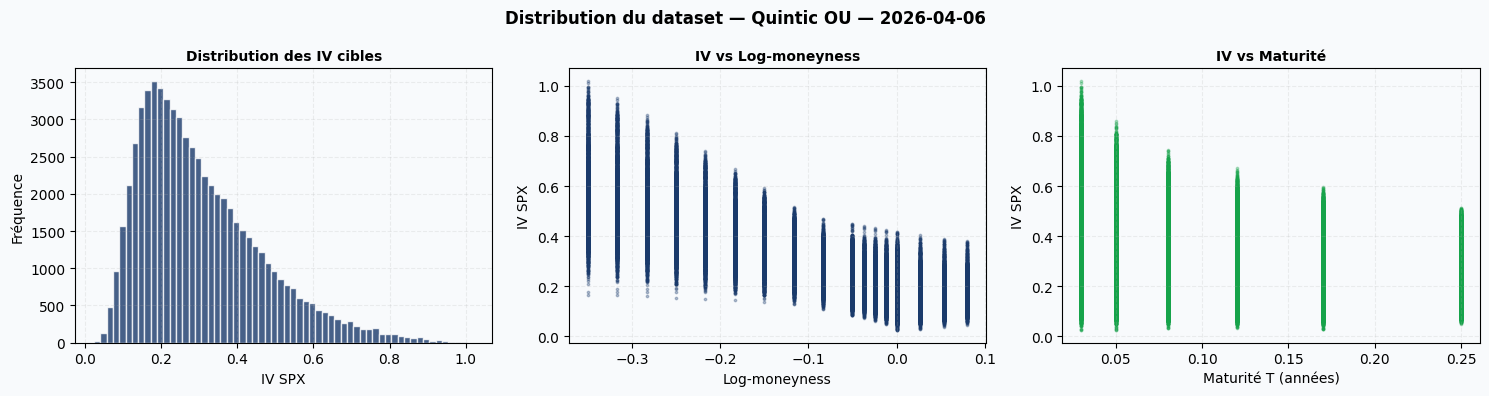

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ━━ CELLULE 5 — GÉNÉRATION DU DATASET ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#
#  [PHASE 1] Modifications par rapport à la version Phase 2 :
#    • MC : mc_spx_parametric(a,b,c) → mc_spx_spline(fv_nodes, T_nodes)
#    • Paramètres aléatoires : (a, b, c) → (fv0, fv1, ..., fv7) — 8 nœuds spline
#    • T_NODES_DATASET : nœuds fixes de la spline (identiques à ceux de la calibration)
#    • FEATURES (16 colonnes) : α₀, α₁, α₃, α₅, H, ρ, fv0..fv7, T, log_moneyness
#
#  TARGET : iv_spx

print("=" * 65)
print(f"  GÉNÉRATION DU DATASET — Quintic OU → SPX IV — {DATE_STR}")
print("=" * 65)

# [MODIF 1] chargement du CSV 06/04
spx_df_raw = pd.read_csv(SPX_FILE)
spx_df_raw = spx_df_raw[spx_df_raw['mid_iv'].between(0.05, 3.0)]
spx_df_raw = spx_df_raw[spx_df_raw['is_otm'] == True]
S0_data    = float(spx_df_raw['S0'].iloc[0])   # 6604.63
print(f"  S0 = {S0_data:.2f}")

# Bornes d'échantillonnage — (a, b, c) remplacés par les 8 nœuds fv de la spline
PARAM_BOUNDS = {
    'alpha0': (0.10,  1.50),
    'alpha1': (0.01,  0.80),   # resserré autour de 0.134
    'alpha3': (0.00,  0.60),   # resserré autour de 0.084
    'alpha5': (0.00,  0.20),   # resserré autour de 0.033
    'H'     : (-0.40, 0.30),   # resserré autour de 0.023
    'rho'   : (-0.95, -0.50),  # resserré autour de -0.744
    'fv0'   : (1e-3,  0.15),
    'fv1'   : (1e-3,  0.15),
    'fv2'   : (1e-3,  0.15),
    'fv3'   : (1e-3,  0.15),
    'fv4'   : (1e-3,  0.15),
    'fv5'   : (1e-3,  0.15),
    'fv6'   : (1e-3,  0.15),
    'fv7'   : (1e-3,  0.15),
}

# [PHASE 1] Nœuds temporels fixes de la spline — identiques à ceux de la calibration
# (correspondent aux T_nodes issus de extract_forward_variance(spx, S0, n_nodes=8))
# ⚠ À mettre à jour avec T_NODES_CAL si différent après relance de la calibration
T_NODES_DATASET = T_NODES_CAL.copy()  # shape (8,)

T_GRID  = [0.03, 0.05, 0.08, 0.12, 0.17, 0.25]
LM_GRID = np.concatenate([
    np.linspace(-0.35, -0.05, 10),
    np.linspace(-0.05,  0.00, 5),
    np.linspace( 0.00,  0.08, 4),
])
print(f"  Maturités : {T_GRID}")
print(f"  Log-moneyness : [{LM_GRID.min():.2f}, {LM_GRID.max():.2f}]  "
      f"({len(LM_GRID)} niveaux)")

N_PARAM  = 600    # était 250 → ~66 000 points
N_MC     = 4000    # [MODIF 2] N_sims pour gen_bm_path (était n_paths=8000)
N_STEPS  = 200     # [MODIF 2] n_steps pour gen_bm_path
SEED_GEN = 2024

rng_gen = np.random.default_rng(SEED_GEN)

print(f"\n  Génération de {N_PARAM} jeux × {len(T_GRID)} maturités × "
      f"{len(LM_GRID)} strikes")
print(f"  ≈ {N_PARAM * len(T_GRID) * len(LM_GRID):,} points (avant filtrage NaN)")
print(f"  MC : N_sims={N_MC}  n_steps={N_STEPS}\n")

# Tirage des paramètres — identique à l'ancien code
params_list = []
for _ in range(N_PARAM):
    p = {}
    for name, (lo, hi) in PARAM_BOUNDS.items():
        p[name] = rng_gen.uniform(lo, hi)
    while p['alpha0'] + p['alpha1'] < 0.30:
        p['alpha0'] = rng_gen.uniform(*PARAM_BOUNDS['alpha0'])
        p['alpha1'] = rng_gen.uniform(*PARAM_BOUNDS['alpha1'])
    params_list.append(p)

# ── Génération des IV par MC ───────────────────────────────────────────────
records = []
t_start = time.time()
n_total = N_PARAM * len(T_GRID)
counter = 0

for i_p, p in enumerate(params_list):
    alpha = np.array([p['alpha0'], p['alpha1'], p['alpha3'], p['alpha5']])
    H     = p['H']
    rho   = p['rho']
    # [PHASE 1] nœuds spline ξ₀ au lieu de (a, b, c)
    fv_nodes = np.array([p['fv0'], p['fv1'], p['fv2'], p['fv3'],
                         p['fv4'], p['fv5'], p['fv6'], p['fv7']])

    for T_mat in T_GRID:
        counter += 1
        strikes = S0_data * np.exp(LM_GRID)

        # Génération du chemin brownien
        seed_mc = SEED_GEN + i_p * 1000 + int(T_mat * 365)
        np.random.seed(seed_mc)
        w1_o = gen_bm_path(N_STEPS, N_MC)
        w1   = np.concatenate((np.zeros(w1_o.shape[1])[np.newaxis, :], w1_o))

        try:
            # [PHASE 1] mc_spx_spline au lieu de mc_spx_parametric
            # Signature : mc_spx_spline(rho, H, eps, T, ak, S0, K, n_steps, N, fv_nodes, T_nodes, w1)
            _, _, ivs_mc, _, _ = mc_spx_spline(
                rho, H, EPS, T_mat, alpha,
                S0_data, strikes,
                N_STEPS, N_MC, fv_nodes, T_NODES_DATASET, w1
            )
        except Exception:
            continue

        for lm, iv in zip(LM_GRID, ivs_mc):
            if np.isnan(iv) or iv <= 0.01 or iv > 3.0:
                continue
            records.append({
                'alpha0'       : p['alpha0'],
                'alpha1'       : p['alpha1'],
                'alpha3'       : p['alpha3'],
                'alpha5'       : p['alpha5'],
                'H'            : H,
                'rho'          : rho,
                # [PHASE 1] fv0..fv7 au lieu de a, b, c
                'fv0'          : p['fv0'],
                'fv1'          : p['fv1'],
                'fv2'          : p['fv2'],
                'fv3'          : p['fv3'],
                'fv4'          : p['fv4'],
                'fv5'          : p['fv5'],
                'fv6'          : p['fv6'],
                'fv7'          : p['fv7'],
                'T'            : T_mat,
                'log_moneyness': lm,
                'iv_spx'       : float(iv),
            })

    if counter % 50 == 0 or counter == n_total:
        elapsed = time.time() - t_start
        eta     = elapsed / counter * (n_total - counter)
        print(f"  [{counter:4d}/{n_total}]  "
              f"points valides : {len(records):,}  |  "
              f"temps : {elapsed:.0f}s  |  ETA : {eta:.0f}s")

# Construction du DataFrame — identique
df_dataset = pd.DataFrame(records)
print(f"\n✅ Dataset généré : {len(df_dataset):,} points valides")
print(f"   Taux de succès : "
      f"{100*len(df_dataset)/(N_PARAM*len(T_GRID)*len(LM_GRID)):.1f}%")

dataset_path = os.path.join(SAVE_DIR, f'dataset_quintic_ou_{DATE_STR}.csv')
df_dataset.to_csv(dataset_path, index=False)
print(f"\n  ✓ Dataset sauvegardé : {dataset_path}")

# Visualisation rapide — identique à l'ancien code
fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor='#f8fafc')
fig.suptitle(f'Distribution du dataset — Quintic OU — {DATE_STR}',
             fontsize=12, fontweight='bold')

axes[0].hist(df_dataset['iv_spx'], bins=60, color='#1a3a6b', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('IV SPX', fontsize=10); axes[0].set_ylabel('Fréquence', fontsize=10)
axes[0].set_title('Distribution des IV cibles', fontsize=10, fontweight='bold')

axes[1].scatter(df_dataset['log_moneyness'], df_dataset['iv_spx'],
                s=3, alpha=0.3, c='#1a3a6b')
axes[1].set_xlabel('Log-moneyness', fontsize=10); axes[1].set_ylabel('IV SPX', fontsize=10)
axes[1].set_title('IV vs Log-moneyness', fontsize=10, fontweight='bold')

axes[2].scatter(df_dataset['T'], df_dataset['iv_spx'],
                s=3, alpha=0.3, c='#16a34a')
axes[2].set_xlabel('Maturité T (années)', fontsize=10)
axes[2].set_ylabel('IV SPX', fontsize=10)
axes[2].set_title('IV vs Maturité', fontsize=10, fontweight='bold')

for ax in axes:
    ax.set_facecolor('#f8fafc'); ax.grid(True, alpha=0.2, ls='--')
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, f'dataset_distribution_{DATE_STR}.png'),
            dpi=150, bbox_inches='tight')
plt.show(); plt.close(fig)



In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ━━ CELLULE 6 — APERÇU ET STATISTIQUES DU DATASET ━━━━━━━━━━━━━━━━━━━━━━━
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Identique à l'ancien code

print("=" * 65)
print(f"  PREMIÈRES LIGNES DU DATASET (8 lignes) — {DATE_STR}")
print("=" * 65)

pd.set_option('display.float_format', '{:.5f}'.format)
pd.set_option('display.max_columns', 12)
pd.set_option('display.width', 120)
print(df_dataset.head(8).to_string(index=True))

print(f"\n  Colonnes : {list(df_dataset.columns)}")
print(f"\n  Statistiques descriptives (iv_spx) :")
print(f"    min={df_dataset['iv_spx'].min():.4f}  "
      f"mean={df_dataset['iv_spx'].mean():.4f}  "
      f"max={df_dataset['iv_spx'].max():.4f}  "
      f"std={df_dataset['iv_spx'].std():.4f}")

print(f"\n  Statistiques complètes :")
print(df_dataset.describe().round(5).to_string())


  PREMIÈRES LIGNES DU DATASET (8 lignes) — 2026-04-06
   alpha0  alpha1  alpha3  alpha5       H      rho     fv0     fv1     fv2     fv3     fv4     fv5     fv6     fv7       T  log_moneyness  iv_spx
0 1.04616 0.17932 0.18567 0.15989 0.29706 -0.88600 0.01273 0.02794 0.05459 0.02627 0.08873 0.09290 0.01670 0.08529 0.08000       -0.35000 0.17782
1 1.04616 0.17932 0.18567 0.15989 0.29706 -0.88600 0.01273 0.02794 0.05459 0.02627 0.08873 0.09290 0.01670 0.08529 0.08000       -0.31667 0.17773
2 1.04616 0.17932 0.18567 0.15989 0.29706 -0.88600 0.01273 0.02794 0.05459 0.02627 0.08873 0.09290 0.01670 0.08529 0.08000       -0.28333 0.17751
3 1.04616 0.17932 0.18567 0.15989 0.29706 -0.88600 0.01273 0.02794 0.05459 0.02627 0.08873 0.09290 0.01670 0.08529 0.08000       -0.25000 0.17693
4 1.04616 0.17932 0.18567 0.15989 0.29706 -0.88600 0.01273 0.02794 0.05459 0.02627 0.08873 0.09290 0.01670 0.08529 0.08000       -0.21667 0.17580
5 1.04616 0.17932 0.18567 0.15989 0.29706 -0.88600 0.01273 0.02794 0.0

  ENTRAÎNEMENT DU RÉSEAU DE NEURONES MLP
  Dataset total   : 65,740 points
  Features        : ['alpha0', 'alpha1', 'alpha3', 'alpha5', 'H', 'rho', 'fv0', 'fv1', 'fv2', 'fv3', 'fv4', 'fv5', 'fv6', 'fv7', 'T', 'log_moneyness']
  Target          : iv_spx

  Train : 52,592 points  |  Test : 13,148 points

  StandardScaler ajusté sur le train.
  Moyennes features : [ 0.779   0.4104  0.3145  0.102  -0.0688 -0.7331  0.0789  0.0749  0.0773
  0.0764  0.0783  0.074   0.0728  0.0757  0.1195 -0.1036]

  Architecture : (512, 256, 128, 64) — activation=relu
  Solver : adam  |  L2 alpha=5e-05  |  max_iter=800
  Early stopping : True  (patience=30)

  ▶ Entraînement en cours...

Iteration 1, loss = 0.00301497
Validation score: 0.955103
Iteration 2, loss = 0.00044126
Validation score: 0.976544
Iteration 3, loss = 0.00027035
Validation score: 0.984460
Iteration 4, loss = 0.00019357
Validation score: 0.988934
Iteration 5, loss = 0.00014625
Validation score: 0.991445
Iteration 6, loss = 0.00011655
Valida

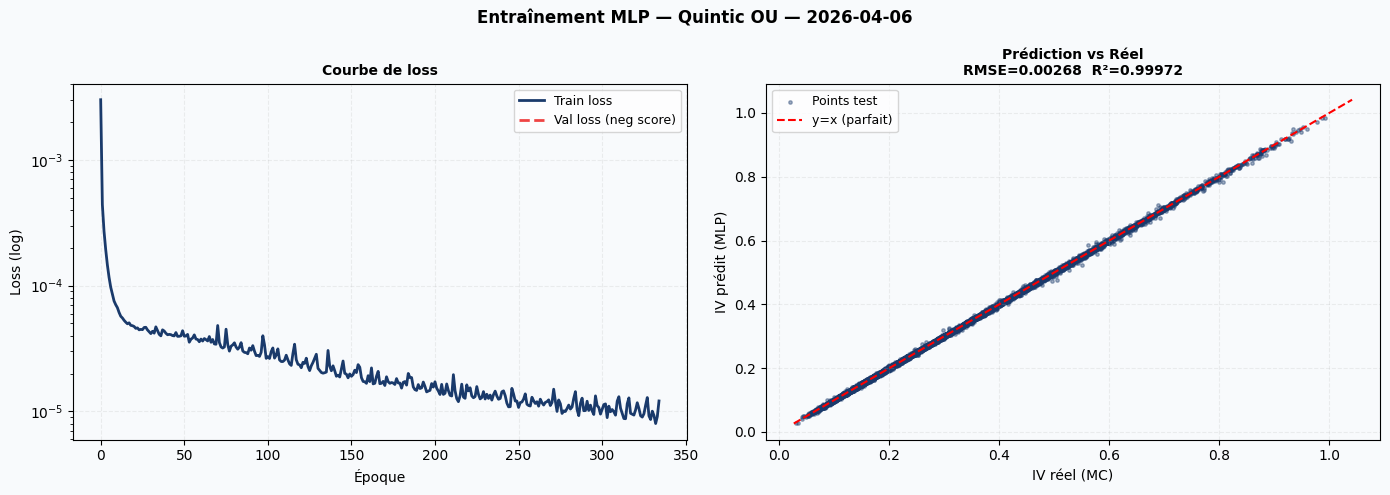

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ━━ CELLULE 7 — ENTRAÎNEMENT DU RÉSEAU DE NEURONES (MLP) ━━━━━━━━━━━━━━━━
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Identique à l'ancien code — aucune modification

print("=" * 65)
print("  ENTRAÎNEMENT DU RÉSEAU DE NEURONES MLP")
print("=" * 65)

# [PHASE 1] 16 features : α₀, α₁, α₃, α₅, H, ρ, fv0..fv7, T, log_moneyness
FEATURE_COLS = ['alpha0', 'alpha1', 'alpha3', 'alpha5',
                'H', 'rho',
                'fv0', 'fv1', 'fv2', 'fv3', 'fv4', 'fv5', 'fv6', 'fv7',
                'T', 'log_moneyness']
TARGET_COL   = 'iv_spx'

X_all = df_dataset[FEATURE_COLS].values.astype(np.float64)
y_all = df_dataset[TARGET_COL].values.astype(np.float64)

print(f"  Dataset total   : {len(X_all):,} points")
print(f"  Features        : {FEATURE_COLS}")
print(f"  Target          : {TARGET_COL}")

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42
)
print(f"\n  Train : {len(X_train):,} points  |  Test : {len(X_test):,} points")

df_test = df_dataset.iloc[
    train_test_split(np.arange(len(df_dataset)), test_size=0.20,
                     random_state=42)[1]
].copy()

scaler_X  = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

print(f"\n  StandardScaler ajusté sur le train.")
print(f"  Moyennes features : {scaler_X.mean_.round(4)}")

mlp = MLPRegressor(
    hidden_layer_sizes=(512, 256, 128, 64),  # était (256, 128, 64) → +1 couche
    activation='relu',
    solver='adam',
    alpha=5e-5,                # légèrement moins de régularisation
    batch_size=512,
    learning_rate='adaptive',
    learning_rate_init=5e-4,   # plus petit pour mieux converger
    max_iter=800,              # était 500
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=30,       # plus de patience
    tol=1e-6,
    random_state=42,
    verbose=True
)

print(f"\n  Architecture : {mlp.hidden_layer_sizes} — activation={mlp.activation}")
print(f"  Solver : {mlp.solver}  |  L2 alpha={mlp.alpha}  |  max_iter={mlp.max_iter}")
print(f"  Early stopping : {mlp.early_stopping}  (patience={mlp.n_iter_no_change})")
print(f"\n  ▶ Entraînement en cours...\n")

t0 = time.time()
mlp.fit(X_train_s, y_train)
t_train = time.time() - t0

print(f"\n  ✅ Entraînement terminé en {t_train:.1f}s")
print(f"  Nombre d'itérations : {mlp.n_iter_}")
print(f"  Meilleure loss validation : {mlp.best_validation_score_:.6f}")

y_pred    = mlp.predict(X_test_s)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
mae_test  = np.mean(np.abs(y_pred - y_test))
r2_test   = r2_score(y_test, y_pred)

print(f"\n  {'='*45}")
print(f"  MÉTRIQUES SUR LE TEST SET (20%)")
print(f"  {'='*45}")
print(f"  RMSE  = {rmse_test:.6f}  (vol implicite)")
print(f"  MAE   = {mae_test:.6f}")
print(f"  R²    = {r2_test:.6f}")
print(f"  {'='*45}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#f8fafc')
fig.suptitle(f'Entraînement MLP — Quintic OU — {DATE_STR}',
             fontsize=12, fontweight='bold')

if hasattr(mlp, 'loss_curve_'):
    axes[0].semilogy(mlp.loss_curve_, color='#1a3a6b', lw=2, label='Train loss')
if hasattr(mlp, 'validation_scores_'):
    axes[0].semilogy([-s for s in mlp.validation_scores_],
                     color='#ef4444', lw=2, ls='--', label='Val loss (neg score)')
axes[0].set_xlabel('Époque', fontsize=10); axes[0].set_ylabel('Loss (log)', fontsize=10)
axes[0].set_title('Courbe de loss', fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.2, ls='--')
axes[0].set_facecolor('#f8fafc')

axes[1].scatter(y_test, y_pred, s=6, alpha=0.4, color='#1a3a6b', label='Points test')
lim = [min(y_test.min(), y_pred.min())*0.95,
       max(y_test.max(), y_pred.max())*1.05]
axes[1].plot(lim, lim, 'r--', lw=1.5, label='y=x (parfait)')
axes[1].set_xlabel('IV réel (MC)', fontsize=10)
axes[1].set_ylabel('IV prédit (MLP)', fontsize=10)
axes[1].set_title(f'Prédiction vs Réel\nRMSE={rmse_test:.5f}  R²={r2_test:.5f}',
                  fontsize=10, fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.2, ls='--')
axes[1].set_facecolor('#f8fafc')

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, f'mlp_training_{DATE_STR}.png'),
            dpi=150, bbox_inches='tight')
print(f"\n  ✓ Figure sauvegardée : mlp_training_{DATE_STR}.png")
plt.show(); plt.close(fig)



In [ ]:
def filter_outlier_ivs(df, lm_col='log_moneyness', iv_col='mid_iv',
                        window=0.05, n_sigma=1):
    df = df.sort_values(lm_col).copy()
    lm  = df[lm_col].values
    iv  = df[iv_col].values
    keep = np.ones(len(df), dtype=bool)
    for i in range(len(df)):
        mask = np.abs(lm - lm[i]) <= window
        local_median = np.median(iv[mask])
        local_std    = np.std(iv[mask]) + 1e-6
        if np.abs(iv[i] - local_median) > n_sigma * local_std:
            keep[i] = False
    return df[keep]

  SMILE SPX : MLP vs Marché vs MC  (données 2026-04-06)
  S0 marché = 6604.63  |  9,828 options OTM filtrées
  Maturités tracées : [11, 18, 29] jours
  ▶ MC référence  T=11j ...
  ▶ MC référence  T=18j ...
  ▶ MC référence  T=29j ...

  ✓ Figure sauvegardée : /content/smile_spx_mlp_vs_market_2026-04-06.png


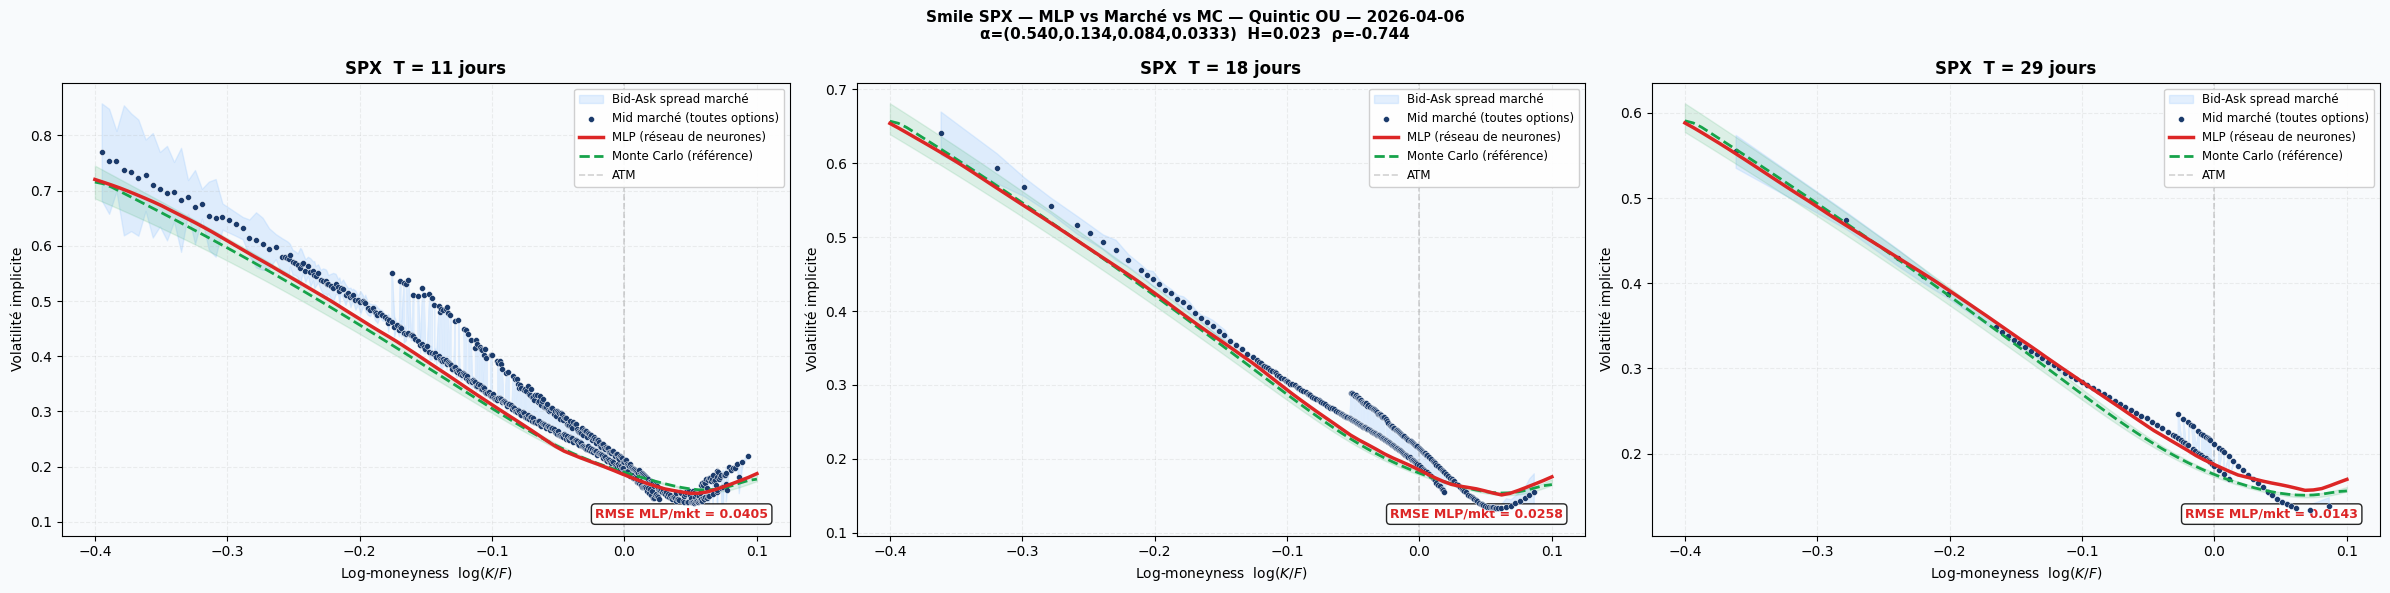

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ━━ CELLULE 8 — SMILE SPX : MLP vs Marché vs MC ━━━━━━━━━━━━━━━━━━━━━━━━━
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#
#  [PHASE 1] Modifications :
#    • Features MLP : A_XI0/B_XI0/C_XI0 → FV_CAL[0..7]  (16 features)
#    • MC de référence : mc_spx_parametric → mc_spx_spline(FV_CAL, T_NODES_CAL)

print("=" * 65)
print(f"  SMILE SPX : MLP vs Marché vs MC  (données {DATE_STR})")
print("=" * 65)


spx_full = pd.read_csv(SPX_FILE)
spx_mkt  = spx_full[spx_full['mid_iv'].between(0.05, 3.0)].copy()
spx_mkt  = spx_mkt[spx_mkt['is_otm'] == True]

# Filtre bid-ask plus strict
spx_mkt  = spx_mkt[(spx_mkt['bid_ask_spread'] /
                     spx_mkt['mid_price'].clip(lower=0.01)) < 0.50]  # était 0.80

# Filtre IV max adapté à chaque maturité
def iv_max_for_T(T):
    if T < 0.05:   return 1.20  # T=11j
    elif T < 0.12: return 1.00  # T=18-29j
    else:          return 0.80  # T=44j+

spx_mkt['iv_max'] = spx_mkt['T'].apply(iv_max_for_T)
spx_mkt = spx_mkt[spx_mkt['mid_iv'] <= spx_mkt['iv_max']].drop(columns='iv_max')


S0       = float(spx_mkt['S0'].iloc[0])
print(f"  S0 marché = {S0:.2f}  |  {len(spx_mkt):,} options OTM filtrées")

avail_T   = sorted(spx_mkt['T'].unique())

# Mêmes maturités que la calibration Phase 1 (3 SPX slices)
T_targets = [0.03, 0.05, 0.08]   # ≈ 11j, 18j, 29j (= Cellule 10)
T_plot    = []
for tgt in T_targets:
    cl = min(avail_T, key=lambda x: abs(x - tgt))
    if cl not in T_plot:
        T_plot.append(cl)
print(f"  Maturités tracées : {[int(round(t*365)) for t in T_plot]} jours")


n_plots = len(T_plot)
fig, axes = plt.subplots(1, n_plots, figsize=(8*n_plots, 6), facecolor='#f8fafc')
if n_plots == 1:
    axes = [axes]

fig.suptitle(
    f'Smile SPX — MLP vs Marché vs MC — Quintic OU — {DATE_STR}\n'
    f'α=({ALPHA_CAL[0]:.3f},{ALPHA_CAL[1]:.3f},'
    f'{ALPHA_CAL[2]:.3f},{ALPHA_CAL[3]:.4f})  '
    f'H={H_CAL:.3f}  ρ={RHO_CAL:.3f}',
    fontsize=11, fontweight='bold'
)

COLORS_PLOT = {
    'market': '#1a3a6b',
    'spread': '#93c5fd',
    'mlp'   : '#dc2626',
    'mc'    : '#16a34a',
}

for ax, T_mat in zip(axes, T_plot):
    days = int(round(T_mat * 365))
    LM_FINE = np.linspace(-0.40, 0.10, 80)
    K_FINE  = S0 * np.exp(LM_FINE)


    sub  = spx_mkt[spx_mkt['T'] == T_mat].sort_values('strike')
    F    = float(sub['forward'].iloc[0])
    ax.set_facecolor('#f8fafc')

    # ── A. POINTS MARCHÉ (TOUS) ────────────────────────────────────────
    iv_max = 1.20 if T_mat < 0.05 else (1.00 if T_mat < 0.12 else 0.80)
    spx_all_T = spx_full[
        (spx_full['T'] == T_mat) &
        (spx_full['mid_iv'].between(0.05, iv_max)) &
        ((spx_full['bid_ask_spread'] /
          spx_full['mid_price'].clip(lower=0.01)) < 0.50)
    ].sort_values('strike')

    spx_all_T = filter_outlier_ivs(spx_all_T)
    lm_all   = np.log(spx_all_T['strike'].values / F)
    iv_all   = spx_all_T['mid_iv'].values
    mask_all = (lm_all > -0.40) & (lm_all < 0.10) & (iv_all > 0.03)

    rel_sp = (spx_all_T['bid_ask_spread'].values
              / spx_all_T['mid_price'].clip(lower=0.01).values)
    iv_bid = np.clip(iv_all - rel_sp*iv_all*0.4, 0.01, None)
    iv_ask = iv_all + rel_sp*iv_all*0.4

    ax.fill_between(lm_all[mask_all], iv_bid[mask_all], iv_ask[mask_all],
                    alpha=0.25, color=COLORS_PLOT['spread'],
                    label='Bid-Ask spread marché')
    ax.scatter(lm_all[mask_all], iv_all[mask_all],
               s=18, color=COLORS_PLOT['market'], zorder=4,
               label='Mid marché (toutes options)', edgecolors='white', lw=0.3)

    # ── B. PRÉDICTION MLP ─────────────────────────────────────────────
    # [PHASE 1] 16 features : α₀, α₁, α₃, α₅, H, ρ, fv0..fv7, T, log_moneyness
    X_mlp = np.column_stack([
        np.full(len(LM_FINE), ALPHA_CAL[0]),   # α₀
        np.full(len(LM_FINE), ALPHA_CAL[1]),   # α₁
        np.full(len(LM_FINE), ALPHA_CAL[2]),   # α₃
        np.full(len(LM_FINE), ALPHA_CAL[3]),   # α₅
        np.full(len(LM_FINE), H_CAL),           # H
        np.full(len(LM_FINE), RHO_CAL),         # ρ
        np.full(len(LM_FINE), FV_CAL[0]),       # fv0  [PHASE 1]
        np.full(len(LM_FINE), FV_CAL[1]),       # fv1  [PHASE 1]
        np.full(len(LM_FINE), FV_CAL[2]),       # fv2  [PHASE 1]
        np.full(len(LM_FINE), FV_CAL[3]),       # fv3  [PHASE 1]
        np.full(len(LM_FINE), FV_CAL[4]),       # fv4  [PHASE 1]
        np.full(len(LM_FINE), FV_CAL[5]),       # fv5  [PHASE 1]
        np.full(len(LM_FINE), FV_CAL[6]),       # fv6  [PHASE 1]
        np.full(len(LM_FINE), FV_CAL[7]),       # fv7  [PHASE 1]
        np.full(len(LM_FINE), T_mat),            # T
        LM_FINE,                                  # log_moneyness
    ])
    X_mlp_s   = scaler_X.transform(X_mlp)
    iv_mlp    = mlp.predict(X_mlp_s)
    valid_mlp = (iv_mlp > 0.02) & (iv_mlp < 3.0)

    ax.plot(LM_FINE[valid_mlp], iv_mlp[valid_mlp], '-',
            color=COLORS_PLOT['mlp'], lw=2.5, zorder=6,
            label='MLP (réseau de neurones)')

    lm_mkt_filt = lm_all[mask_all]
    iv_mkt_filt = iv_all[mask_all]
    in_range    = (lm_mkt_filt >= LM_FINE[valid_mlp].min()) & \
                  (lm_mkt_filt <= LM_FINE[valid_mlp].max())
    if in_range.sum() > 3:
        iv_mlp_on_mkt = np.interp(lm_mkt_filt[in_range],
                                   LM_FINE[valid_mlp], iv_mlp[valid_mlp])
        rmse_mlp = np.sqrt(np.mean((iv_mlp_on_mkt - iv_mkt_filt[in_range])**2))
        ax.text(0.97, 0.04,
                f'RMSE MLP/mkt = {rmse_mlp:.4f}',
                transform=ax.transAxes, ha='right', fontsize=9,
                color=COLORS_PLOT['mlp'], fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

    # ── C. COURBE MC DE RÉFÉRENCE ─────────────────────────────────────
    # [PHASE 1] mc_spx_spline + FV_CAL/T_NODES_CAL au lieu de mc_spx_parametric
    print(f"  ▶ MC référence  T={days}j ...")
    try:
        np.random.seed(99)
        w1_ref_o = gen_bm_path(N_STEPS, 2500)
        w1_ref   = np.concatenate((np.zeros(w1_ref_o.shape[1])[np.newaxis, :], w1_ref_o))

        _, _, iv_mc_ref, iv_mc_u, iv_mc_l = mc_spx_spline(
            RHO_CAL, H_CAL, EPS, T_mat,
            ALPHA_CAL,                   # np.array([α₀,α₁,α₃,α₅])
            S0, K_FINE,
            N_STEPS, 2500, FV_CAL, T_NODES_CAL,   # [PHASE 1] spline nodes
            w1_ref
        )
        valid_mc = (~np.isnan(iv_mc_ref)) & (iv_mc_ref > 0.02) & (iv_mc_ref < 3.0)
        if valid_mc.sum() >= 4:
            from scipy.ndimage import uniform_filter1d
            iv_mc_smooth = uniform_filter1d(iv_mc_ref[valid_mc], size=5)
            ax.plot(LM_FINE[valid_mc], iv_mc_smooth, '--',
                    color=COLORS_PLOT['mc'], lw=2.0, zorder=5,
                    label='Monte Carlo (référence)')
            ax.fill_between(LM_FINE[valid_mc],
                            iv_mc_l[valid_mc], iv_mc_u[valid_mc],
                            alpha=0.12, color=COLORS_PLOT['mc'])
    except Exception as e:
        print(f"    ⚠ MC échoué : {e}")

    ax.axvline(0, color='gray', ls='--', alpha=0.35, lw=1.2, label='ATM')
    ax.set_title(f'SPX  T = {days} jours', fontsize=12, fontweight='bold')
    ax.set_xlabel(r'Log-moneyness  $\log(K/F)$', fontsize=10)
    ax.set_ylabel('Volatilité implicite', fontsize=10)
    ax.legend(fontsize=8.5, loc='upper right', framealpha=0.92)
    ax.grid(True, alpha=0.2, ls='--')

fig.tight_layout()
path_smile = os.path.join(SAVE_DIR, f'smile_spx_mlp_vs_market_{DATE_STR}.png')
fig.savefig(path_smile, dpi=160, bbox_inches='tight')
print(f"\n  ✓ Figure sauvegardée : {path_smile}")
plt.show()
plt.close(fig)


  ANALYSE DES RÉSIDUS SUR LE TEST SET (20%) — 2026-04-06
  RMSE      = 0.002679
  MAE       = 0.001889
  Err rel   = 0.0077 (0.77%)
  % < 1 vp  = 99.3%
  % < 2 vp  = 99.9%
  R²        = 0.999721

  ✓ Figure sauvegardée : /content/mlp_residuals_analysis_2026-04-06.png


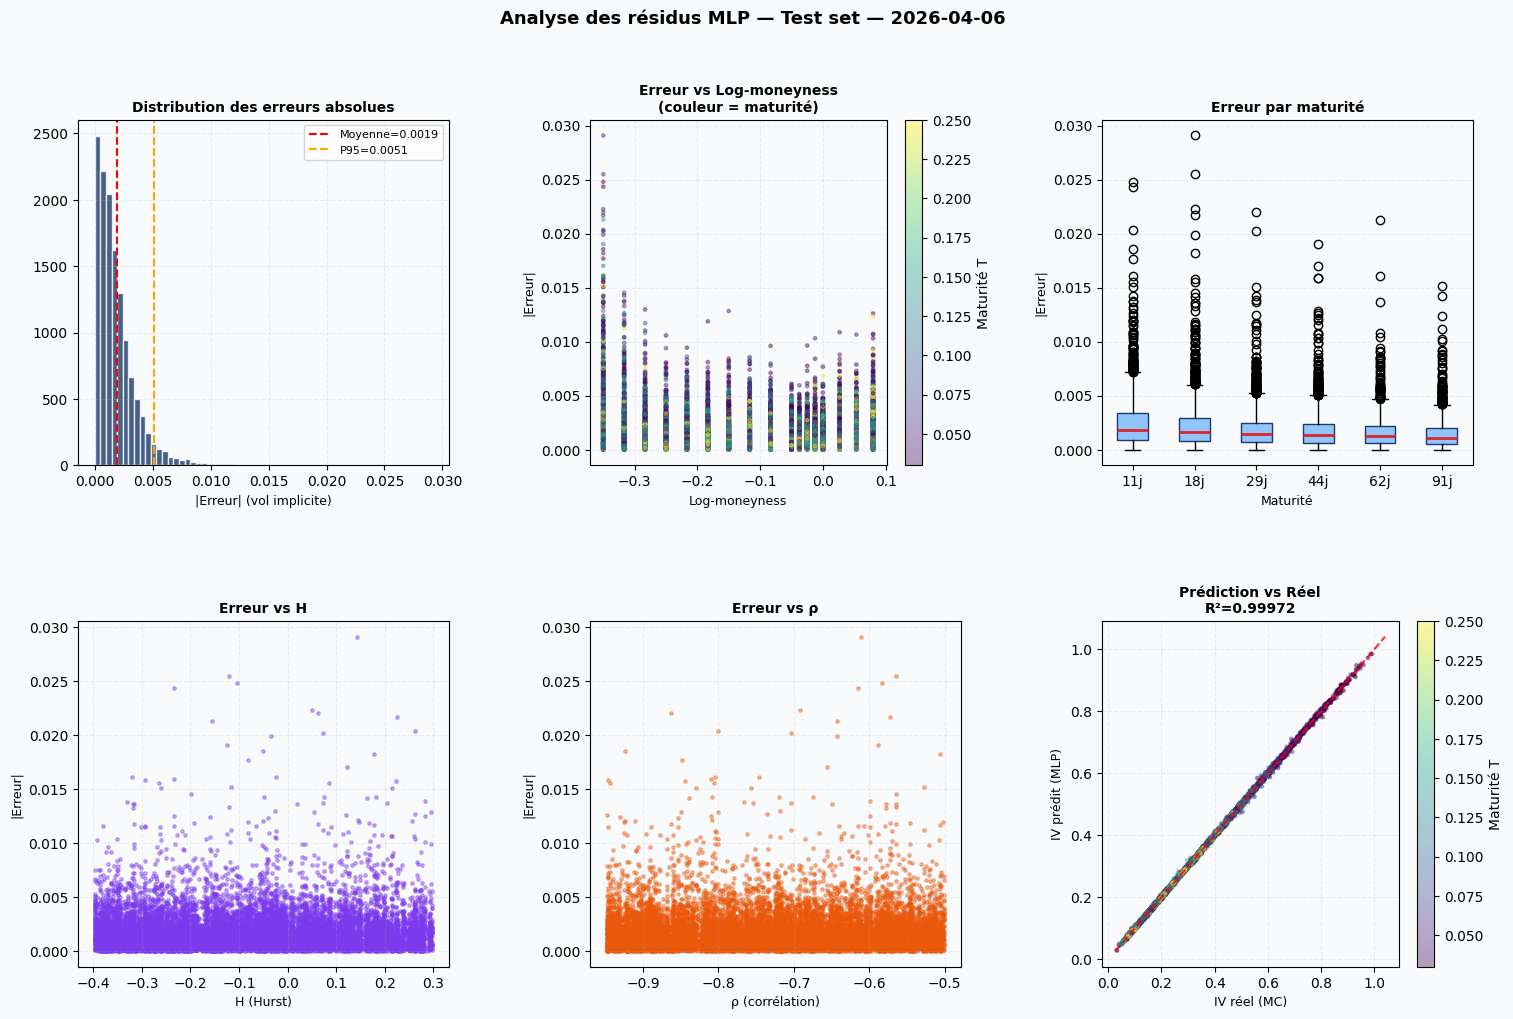

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ━━ CELLULE 9 — ANALYSE DES RÉSIDUS SUR LE TEST SET ━━━━━━━━━━━━━━━━━━━━━
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Identique à l'ancien code — aucune modification

print("=" * 65)
print(f"  ANALYSE DES RÉSIDUS SUR LE TEST SET (20%) — {DATE_STR}")
print("=" * 65)

errors_abs = np.abs(y_pred - y_test)
errors_rel = errors_abs / np.maximum(y_test, 0.01)

print(f"  RMSE      = {rmse_test:.6f}")
print(f"  MAE       = {mae_test:.6f}")
print(f"  Err rel   = {errors_rel.mean():.4f} ({errors_rel.mean()*100:.2f}%)")
print(f"  % < 1 vp  = {(errors_abs < 0.01).mean()*100:.1f}%")
print(f"  % < 2 vp  = {(errors_abs < 0.02).mean()*100:.1f}%")
print(f"  R²        = {r2_test:.6f}")

fig = plt.figure(figsize=(18, 11), facecolor='#f8fafc')
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.38)
axes_res = [fig.add_subplot(gs[i//3, i%3]) for i in range(6)]
fig.suptitle(f'Analyse des résidus MLP — Test set — {DATE_STR}',
             fontsize=13, fontweight='bold')

df_test_arr = X_test
# [PHASE 1] indices mis à jour : 16 features → T à l'indice 14, LM à l'indice 15
T_test   = df_test_arr[:, 14]   # était 9  (11 features) → 14 (16 features)
LM_test  = df_test_arr[:, 15]   # était 10 (11 features) → 15 (16 features)
H_test   = df_test_arr[:, 4]    # inchangé
RHO_test = df_test_arr[:, 5]    # inchangé

# 1. Histogramme erreurs absolues
axes_res[0].hist(errors_abs, bins=60, color='#1a3a6b', alpha=0.8, edgecolor='white')
axes_res[0].axvline(errors_abs.mean(), color='red', ls='--', lw=1.5,
                    label=f'Moyenne={errors_abs.mean():.4f}')
axes_res[0].axvline(np.percentile(errors_abs, 95), color='orange', ls='--', lw=1.5,
                    label=f'P95={np.percentile(errors_abs, 95):.4f}')
axes_res[0].set_xlabel('|Erreur| (vol implicite)', fontsize=9)
axes_res[0].set_title('Distribution des erreurs absolues', fontsize=10, fontweight='bold')
axes_res[0].legend(fontsize=8); axes_res[0].grid(True, alpha=0.2, ls='--')

# 2. Erreur vs log-moneyness
sc2 = axes_res[1].scatter(LM_test, errors_abs, s=6, alpha=0.4,
                            c=T_test, cmap='viridis')
plt.colorbar(sc2, ax=axes_res[1], label='Maturité T')
axes_res[1].set_xlabel('Log-moneyness', fontsize=9)
axes_res[1].set_ylabel('|Erreur|', fontsize=9)
axes_res[1].set_title('Erreur vs Log-moneyness\n(couleur = maturité)',
                       fontsize=10, fontweight='bold')
axes_res[1].grid(True, alpha=0.2, ls='--')

# 3. Erreur vs maturité (boxplot)
T_unique   = sorted(np.unique(np.round(T_test, 3)))
box_data   = [errors_abs[np.abs(T_test - t) < 0.005] for t in T_unique]
box_labels = [f'{int(round(t*365))}j' for t in T_unique]
axes_res[2].boxplot(box_data, labels=box_labels, patch_artist=True,
                    boxprops=dict(facecolor='#93c5fd', color='#1a3a6b'),
                    medianprops=dict(color='#dc2626', lw=2))
axes_res[2].set_xlabel('Maturité', fontsize=9)
axes_res[2].set_ylabel('|Erreur|', fontsize=9)
axes_res[2].set_title('Erreur par maturité', fontsize=10, fontweight='bold')
axes_res[2].grid(True, alpha=0.2, ls='--', axis='y')

# 4. Erreur vs H
axes_res[3].scatter(H_test, errors_abs, s=6, alpha=0.4, color='#7c3aed')
axes_res[3].set_xlabel('H (Hurst)', fontsize=9)
axes_res[3].set_ylabel('|Erreur|', fontsize=9)
axes_res[3].set_title('Erreur vs H', fontsize=10, fontweight='bold')
axes_res[3].grid(True, alpha=0.2, ls='--')

# 5. Erreur vs ρ
axes_res[4].scatter(RHO_test, errors_abs, s=6, alpha=0.4, color='#ea580c')
axes_res[4].set_xlabel('ρ (corrélation)', fontsize=9)
axes_res[4].set_ylabel('|Erreur|', fontsize=9)
axes_res[4].set_title('Erreur vs ρ', fontsize=10, fontweight='bold')
axes_res[4].grid(True, alpha=0.2, ls='--')

# 6. Prédiction vs réel
sc6 = axes_res[5].scatter(y_test, y_pred, s=6, alpha=0.4, c=T_test, cmap='viridis')
plt.colorbar(sc6, ax=axes_res[5], label='Maturité T')
lim6 = [min(y_test.min(), y_pred.min())*0.95,
        max(y_test.max(), y_pred.max())*1.05]
axes_res[5].plot(lim6, lim6, 'r--', lw=1.5, alpha=0.8)
axes_res[5].set_xlabel('IV réel (MC)', fontsize=9)
axes_res[5].set_ylabel('IV prédit (MLP)', fontsize=9)
axes_res[5].set_title(f'Prédiction vs Réel\nR²={r2_test:.5f}',
                       fontsize=10, fontweight='bold')
axes_res[5].grid(True, alpha=0.2, ls='--')

for ax in axes_res:
    ax.set_facecolor('#f8fafc')

fig.tight_layout()
path_res = os.path.join(SAVE_DIR, f'mlp_residuals_analysis_{DATE_STR}.png')
fig.savefig(path_res, dpi=150, bbox_inches='tight')
print(f"\n  ✓ Figure sauvegardée : {path_res}")
plt.show(); plt.close(fig)


  SMILE SPX : MLP vs Marché (test set) — 2026-04-06
  Maturités test : [11, 18, 29] jours

  ✓ Figure sauvegardée : /content/smile_spx_test_set_2026-04-06.png


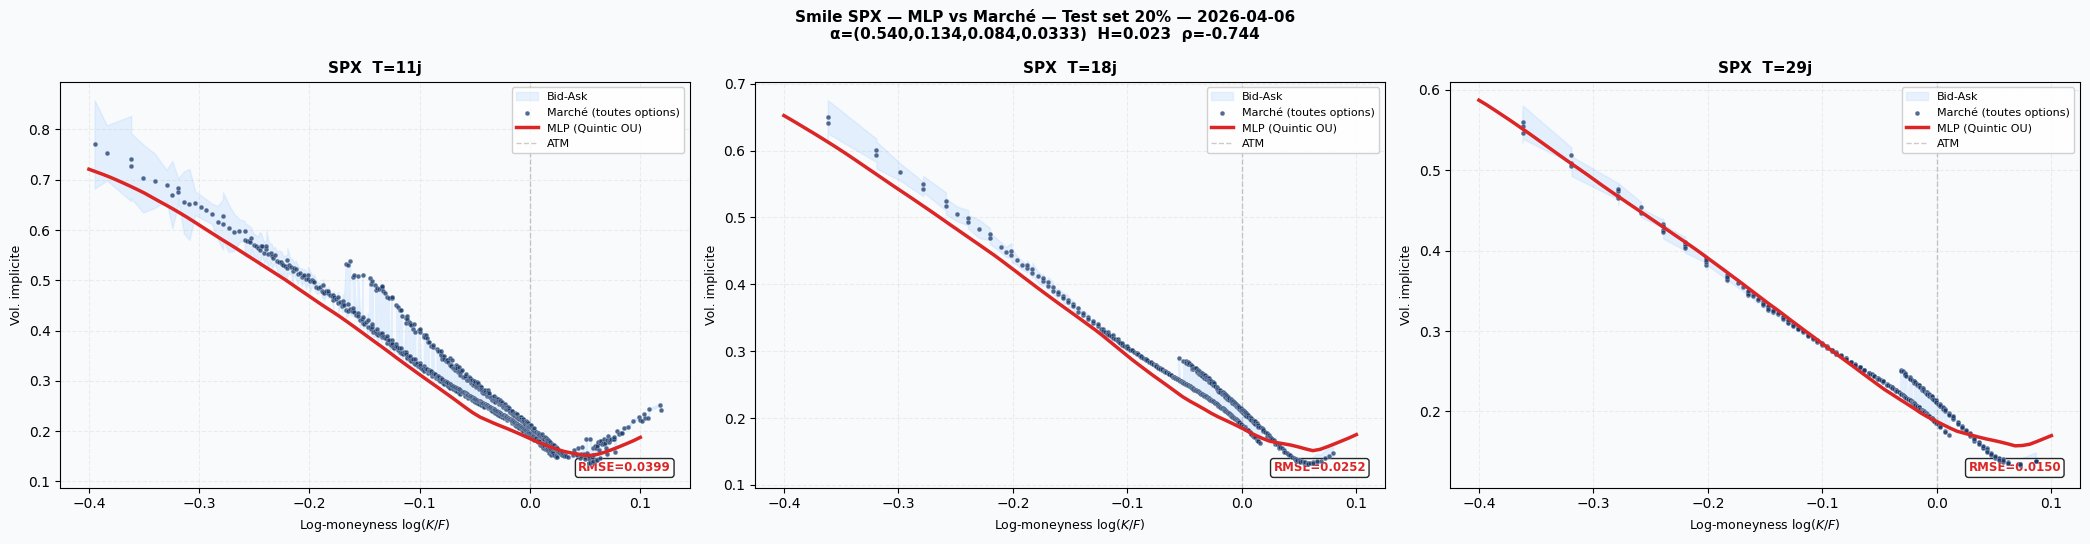


  ✅ PIPELINE COMPLET TERMINÉ — 2026-04-06
  Dataset    : 65,740 points  → /content/dataset_quintic_ou_2026-04-06.csv
  MLP        : RMSE=0.00268  R²=0.99972
  Figures    : /content/*.png
  Paramètres calibrés utilisés (Phase 1 — ξ₀ spline) :
    α = [0.5396, 0.1344, 0.0835, 0.033342]
    H = 0.0228  ρ = -0.7444  ε = 0.019231
    fv_nodes = [0.039453, 0.075359, 0.070672, 0.065698, 0.055241, 0.102626, 0.028886, 0.105497]
    T_nodes  = [0.0, 0.158904, 0.317808, 0.476712, 0.635616, 0.794521, 0.953425, 1.112329]


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ━━ CELLULE 10 — SMILE SPX SUR LE TEST SET (petits points marché) ━━━━━━━━
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#
#  [PHASE 1] Modifications :
#    • Features MLP : FV_CAL[0..7] au lieu de A_XI0/B_XI0/C_XI0
#    • Indice de T dans X_test : 9 → 14  (16 features)

print("=" * 65)
print(f"  SMILE SPX : MLP vs Marché (test set) — {DATE_STR}")
print("=" * 65)

# Maturités cibles : 11j, 18j, 29j (= calibration Phase 1)
T_targets = [0.03, 0.05, 0.08]   # ≈ 11j, 18j, 29j
available  = np.unique(np.round(X_test[:, 14], 3))
T_in_test  = []
for tgt in T_targets:
    closest = min(available, key=lambda x: abs(x - tgt))
    if abs(closest - tgt) < 0.05 and closest not in T_in_test:  # seuil 0.05
        T_in_test.append(closest)
print(f"  Maturités test : {[int(round(t*365)) for t in T_in_test]} jours")

n_T   = len(T_in_test)
ncols = min(n_T, 3)
nrows = math.ceil(n_T / ncols)

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(7*ncols, 5.5*nrows),
                          facecolor='#f8fafc')
axes_flat = np.array(axes).flatten() if n_T > 1 else [axes]

fig.suptitle(
    f'Smile SPX — MLP vs Marché — Test set 20% — {DATE_STR}\n'
    f'α=({ALPHA_CAL[0]:.3f},{ALPHA_CAL[1]:.3f},'
    f'{ALPHA_CAL[2]:.3f},{ALPHA_CAL[3]:.4f})  '
    f'H={H_CAL:.3f}  ρ={RHO_CAL:.3f}',
    fontsize=11, fontweight='bold'
)

for idx, T_mat in enumerate(T_in_test):
    ax   = axes_flat[idx]
    days = int(round(T_mat * 365))
    LM_FINE = np.linspace(-0.40, 0.10, 80)
    ax.set_facecolor('#f8fafc')

    # Données marché 06/04
    iv_max = 1.20 if T_mat < 0.05 else (1.00 if T_mat < 0.12 else 0.80)
    spx_T = spx_full[
        (np.abs(spx_full['T'] - T_mat) < 0.005) &
        (spx_full['mid_iv'].between(0.04, iv_max)) &
        ((spx_full['bid_ask_spread'] /
          spx_full['mid_price'].clip(lower=0.01)) < 0.50)
    ].sort_values('strike')
    spx_T = spx_T[
        (spx_T['bid_ask_spread'] /
         spx_T['mid_price'].clip(lower=0.01)) < 0.30
    ]
    spx_T = filter_outlier_ivs(spx_T, n_sigma=1.0)

    if len(spx_T) == 0:
        ax.text(0.5, 0.5, f'Pas de données marché\npour T={days}j',
                transform=ax.transAxes, ha='center', fontsize=10)
        ax.set_title(f'SPX  T={days}j', fontsize=10, fontweight='bold')
        continue

    F      = float(spx_T['forward'].iloc[0]) if 'forward' in spx_T.columns else S0
    lm_mkt = np.log(spx_T['strike'].values / F)
    iv_mkt = spx_T['mid_iv'].values
    mask_mkt = (lm_mkt > -0.40) & (lm_mkt < 0.12) & (iv_mkt > 0.03)

    rel_sp = (spx_T['bid_ask_spread'].values /
              spx_T['mid_price'].clip(lower=0.01).values)
    iv_bid = np.clip(iv_mkt - rel_sp*iv_mkt*0.4, 0.01, None)
    iv_ask = iv_mkt + rel_sp*iv_mkt*0.4

    ax.fill_between(lm_mkt[mask_mkt], iv_bid[mask_mkt], iv_ask[mask_mkt],
                    alpha=0.20, color='#93c5fd', label='Bid-Ask')
    ax.scatter(lm_mkt[mask_mkt], iv_mkt[mask_mkt],
               s=12, color='#1a3a6b', alpha=0.75, zorder=4,
               label='Marché (toutes options)', edgecolors='white', lw=0.2)

    # Courbe MLP avec paramètres calibrés 06/04
    # [PHASE 1] fv0..fv7 : nœuds spline ξ₀ calibrés (Phase 1)
    # [PHASE 1] 16 features : α₀..α₅, H, ρ, fv0..fv7, T, log_moneyness
    X_mlp_T = np.column_stack([
        np.full(len(LM_FINE), ALPHA_CAL[0]),
        np.full(len(LM_FINE), ALPHA_CAL[1]),
        np.full(len(LM_FINE), ALPHA_CAL[2]),
        np.full(len(LM_FINE), ALPHA_CAL[3]),
        np.full(len(LM_FINE), H_CAL),
        np.full(len(LM_FINE), RHO_CAL),
        np.full(len(LM_FINE), FV_CAL[0]),   # fv0  [PHASE 1]
        np.full(len(LM_FINE), FV_CAL[1]),   # fv1  [PHASE 1]
        np.full(len(LM_FINE), FV_CAL[2]),   # fv2  [PHASE 1]
        np.full(len(LM_FINE), FV_CAL[3]),   # fv3  [PHASE 1]
        np.full(len(LM_FINE), FV_CAL[4]),   # fv4  [PHASE 1]
        np.full(len(LM_FINE), FV_CAL[5]),   # fv5  [PHASE 1]
        np.full(len(LM_FINE), FV_CAL[6]),   # fv6  [PHASE 1]
        np.full(len(LM_FINE), FV_CAL[7]),   # fv7  [PHASE 1]
        np.full(len(LM_FINE), T_mat),
        LM_FINE,
    ])
    X_mlp_T_s = scaler_X.transform(X_mlp_T)
    iv_mlp_T  = mlp.predict(X_mlp_T_s)
    valid_T   = (iv_mlp_T > 0.02) & (iv_mlp_T < 3.0)

    ax.plot(LM_FINE[valid_T], iv_mlp_T[valid_T], '-',
            color='#dc2626', lw=2.5, zorder=6, label='MLP (Quintic OU)')

    in_rng = (lm_mkt[mask_mkt] >= LM_FINE[valid_T].min()) & \
             (lm_mkt[mask_mkt] <= LM_FINE[valid_T].max())
    if in_rng.sum() > 2:
        iv_mlp_interp = np.interp(lm_mkt[mask_mkt][in_rng],
                                   LM_FINE[valid_T], iv_mlp_T[valid_T])
        rmse_T = np.sqrt(np.mean((iv_mlp_interp - iv_mkt[mask_mkt][in_rng])**2))
        ax.text(0.97, 0.04, f'RMSE={rmse_T:.4f}',
                transform=ax.transAxes, ha='right', fontsize=8.5,
                color='#dc2626', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.85))

    ax.axvline(0, color='gray', ls='--', alpha=0.4, lw=1, label='ATM')
    ax.set_title(f'SPX  T={days}j', fontsize=11, fontweight='bold')
    ax.set_xlabel(r'Log-moneyness $\log(K/F)$', fontsize=9)
    ax.set_ylabel('Vol. implicite', fontsize=9)
    ax.legend(fontsize=8, loc='upper right', framealpha=0.9)
    ax.grid(True, alpha=0.2, ls='--')

for idx in range(len(T_in_test), len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.tight_layout()
path_test = os.path.join(SAVE_DIR, f'smile_spx_test_set_{DATE_STR}.png')
fig.savefig(path_test, dpi=160, bbox_inches='tight')
print(f"\n  ✓ Figure sauvegardée : {path_test}")
plt.show(); plt.close(fig)

print(f"\n{'='*65}")
print(f"  ✅ PIPELINE COMPLET TERMINÉ — {DATE_STR}")
print(f"{'='*65}")
print(f"  Dataset    : {len(df_dataset):,} points  → {dataset_path}")
print(f"  MLP        : RMSE={rmse_test:.5f}  R²={r2_test:.5f}")
print(f"  Figures    : /content/*.png")
print(f"  Paramètres calibrés utilisés (Phase 1 — ξ₀ spline) :")
print(f"    α = {ALPHA_CAL.tolist()}")
print(f"    H = {H_CAL}  ρ = {RHO_CAL}  ε = {EPS:.6f}")
print(f"    fv_nodes = {FV_CAL.tolist()}")
print(f"    T_nodes  = {T_NODES_CAL.tolist()}")
print(f"{'='*65}")